# David's Simulated Data KF Estimation Analysis

- fit an SLDS model on sim_data.h5
- apply regular and parameter-adaptive Kalman filters on step trials
- manually tuning filter noise parameters
- compare estimated latent states to true simulated states with a 4x4 state-basis transform


## Setup and imports


In [71]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.linalg import solve_discrete_are
from scipy.ndimage import gaussian_filter1d

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "NDACPython":
    project_candidate = PROJECT_DIR / "NDACPython"
    if project_candidate.exists():
        PROJECT_DIR = project_candidate

python_tag = f"lib.win-amd64-cpython-{sys.version_info.major}{sys.version_info.minor}"
ssm_build_candidates = sorted((PROJECT_DIR / "ssm" / "build").glob("lib.win-amd64-cpython-*"))
preferred_build_dir = PROJECT_DIR / "ssm" / "build" / python_tag
import_dirs = []
if preferred_build_dir.exists():
    import_dirs.append(preferred_build_dir)
for candidate in ssm_build_candidates:
    if candidate not in import_dirs:
        import_dirs.append(candidate)
import_dirs.extend([PROJECT_DIR, PROJECT_DIR / "ssm"])
for candidate in reversed(import_dirs):
    candidate_str = str(candidate)
    if candidate.exists() and candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

from main1 import OnlineSLDSModel
from test_kf_utils import plot_model_matrix_grid

## Configuration


In [72]:
SIM_DATA_PATH = (PROJECT_DIR.parent / "sim_data.h5").resolve()

FIT_METHOD = "laplace_em"
FIT_INITIALIZE = False
FIT_NUM_ITERS = 25
VARIATIONAL_POSTERIOR = "structured_meanfield"
FIT_ALPHA = 0.5
FIT_NUM_SAMPLES = 10

DT = 0.01
BIN_MS = int(round(DT * 1000))
SMOOTH_STD_MS = 25.0
SMOOTH_STD_BINS = SMOOTH_STD_MS / BIN_MS

FITTED_LATENT_DIM = 4
FITTED_CHANNEL_LABELS = [1]
FIT_CHANNEL_INDICES = [5]

WHITE_NOISE_TRIALS = np.arange(0, 75, dtype=int)
STEP_TRIALS = np.arange(75, 400, dtype=int)
INPUT_DIM_INDEX = 1

DEFAULT_Q_SCALE = 0.05
DEFAULT_QMU_SCALE = 0.05
DEFAULT_R_SCALE = 1.0
INIT_COV_SCALE = 1e-2

## Load and preprocess simulation data


In [73]:
with h5py.File(SIM_DATA_PATH, "r") as h5f:
    us = np.asarray(h5f["us"][:], dtype=float)
    xs = np.asarray(h5f["xs"][:], dtype=float)
    ys = np.asarray(h5f["ys"][:], dtype=float)
    zs = np.asarray(h5f["zs"][:], dtype=int)

n_trials, n_bins, n_y_channels = ys.shape
time_s = np.arange(n_bins, dtype=float) * DT
y_raw_rate_hz = ys / DT
y_rate_hz = gaussian_filter1d(y_raw_rate_hz, sigma=SMOOTH_STD_BINS, axis=1, mode="nearest")
u_model_all = us[:, :, [INPUT_DIM_INDEX]]
light_intensity = np.max(u_model_all[:, :, 0], axis=1)

step_nonzero = np.abs(u_model_all[STEP_TRIALS, :, 0]) > 1e-9
stim_mask = np.any(step_nonzero, axis=0)
stim_start_bin = int(np.flatnonzero(stim_mask)[0])
stim_stop_bin = int(np.flatnonzero(stim_mask)[-1]) + 1
stim_start_s = stim_start_bin * DT
stim_stop_s = stim_stop_bin * DT
trial_duration_s = n_bins * DT

baseline_rate = y_rate_hz[STEP_TRIALS, :stim_start_bin, :].mean(axis=(0, 1))
y_train = [y_rate_hz[i][:, FIT_CHANNEL_INDICES] - baseline_rate[FIT_CHANNEL_INDICES][None, :] for i in WHITE_NOISE_TRIALS]
u_train = [u_model_all[i] for i in WHITE_NOISE_TRIALS]


step_level_counts = pd.Series(np.round(light_intensity[STEP_TRIALS], 6)).value_counts().sort_index()
dataset_summary = pd.DataFrame(
    {
        "item": [
            "n_trials_total",
            "n_trials_white_noise",
            "n_trials_step",
            "n_bins_per_trial",
            "trial_duration_s",
            "stim_start_s_detected",
            "stim_stop_s_detected",
            "smooth_sigma_ms",
        ],
        "value": [
            n_trials,
            len(WHITE_NOISE_TRIALS),
            len(STEP_TRIALS),
            n_bins,
            trial_duration_s,
            stim_start_s,
            stim_stop_s,
            SMOOTH_STD_MS,
        ],
    }
)
display(dataset_summary)
display(step_level_counts.rename_axis("step_intensity").reset_index(name="n_trials"))

print("Using the actual dataset timing from sim_data.h5.")
print(f"Detected trial duration = {trial_duration_s:.3f} s from {n_bins} bins at {1/DT:.0f} Hz.")
print(f"Detected step window = [{stim_start_s:.3f}, {stim_stop_s:.3f}) s, which differs from the requested 0.1/3.1 s markers.")
print("z is ignored for fitting and filtering, but it is still shown in Section 4 as requested.")
print(f"Model fitting uses baseline-subtracted, Gaussian-smoothed firing rate with sigma = {SMOOTH_STD_MS:.0f} ms.")

,item,value
0,n_trials_total,400.0
1,n_trials_white_noise,75.0
2,n_trials_step,325.0
3,n_bins_per_trial,340.0
4,trial_duration_s,3.4
5,stim_start_s_detected,0.2
6,stim_stop_s_detected,3.2
7,smooth_sigma_ms,25.0


,step_intensity,n_trials
0,0.1,109
1,0.2,108
2,0.3,108


Using the actual dataset timing from sim_data.h5.
Detected trial duration = 3.400 s from 340 bins at 100 Hz.
Detected step window = [0.200, 3.200) s, which differs from the requested 0.1/3.1 s markers.
z is ignored for fitting and filtering, but it is still shown in Section 4 as requested.
Model fitting uses baseline-subtracted, Gaussian-smoothed firing rate with sigma = 25 ms.


## Fit the SLDS model


In [74]:
# fit the model with ssm SLDS.fit
ssm_model = OnlineSLDSModel(
    N=y_train[0].shape[1],
    D=FITTED_LATENT_DIM,
    K=1,
    M=1,
    transitions="recurrent_only",
    dynamics="gaussian",
    emissions="gaussian",
    dt=DT,
    alpha_variance=0.99,
    x_variance=1.1,
    SigmasScaler=0.1,
    with_noise=True,
)
_fit_elbos, _fit_posterior = ssm_model.fit(
    y_train,
    inputs=u_train,
    method=FIT_METHOD,
    variational_posterior=VARIATIONAL_POSTERIOR,
    initialize=FIT_INITIALIZE,
    num_iters=FIT_NUM_ITERS,
    alpha=FIT_ALPHA,
    num_samples=FIT_NUM_SAMPLES,
)

ssm_model.emissions.inv_etas = np.log(np.maximum(np.exp(ssm_model.emissions.inv_etas), 1e-3))

A_fit = np.asarray(ssm_model.dynamics.As[0], dtype=float)
B_fit = np.asarray(ssm_model.dynamics.Vs[0], dtype=float)
b_fit = np.asarray(ssm_model.dynamics.bs[0], dtype=float).reshape(-1)
C_fit = np.asarray(ssm_model.emissions.Cs[0], dtype=float)
d_residual_fit = np.asarray(ssm_model.emissions.ds[0], dtype=float).reshape(-1)
d_fit = d_residual_fit + np.asarray(baseline_rate[FIT_CHANNEL_INDICES], dtype=float)

Q_fit_base = np.diag(np.diag(np.asarray(ssm_model.dynamics.Sigmas[0], dtype=float)))
R_fit = np.diag(np.exp(np.asarray(ssm_model.emissions.inv_etas[0], dtype=float)))
R_fit = np.asarray(R_fit, dtype=float) + 1e-6 * np.eye(R_fit.shape[0], dtype=float)
P_ss = solve_discrete_are(A_fit.T, C_fit.T, Q_fit_base, R_fit)
K_ss = P_ss @ C_fit.T @ np.linalg.pinv(C_fit @ P_ss @ C_fit.T + R_fit)

ssm_model_params = {
    "A": A_fit,
    "B": B_fit,
    "b": b_fit,
    "C": C_fit,
    "d": d_fit,
    "D": int(A_fit.shape[0]),
    "M": int(B_fit.shape[1]),
    "N": int(C_fit.shape[0]),
    "Q_fit_base": Q_fit_base,
    "R_fit": R_fit,
    "Kalman_gain": K_ss,
}


print("Fit complete using ssm SLDS class")
print("A shape:", ssm_model_params["A"].shape)
print("B shape:", ssm_model_params["B"].shape)
print("C shape:", ssm_model_params["C"].shape)
print("Q_fit_base diag:", np.diag(ssm_model_params["Q_fit_base"]))
print("Residual fit d (from ssm fit):", d_residual_fit)
print("Absolute output d (adding ssm fit d to the detected baseline rate):", ssm_model_params["d"])
print("R_fit diag min/max:", float(np.min(np.diag(ssm_model_params["R_fit"]))), float(np.max(np.diag(ssm_model_params["R_fit"]))))


c:\Users\jxiao85\Documents\ContinuousSystemControl\NDACPython\ssm\build\lib.win-amd64-cpython-313\ssm\variational.py:348: UserWarning: We can only initialize the continuous states if the emissions support "inverting" the observations by mapping them to an estimate of the latent states. Defaulting to a random initialization instead.
  warn("We can only initialize the continuous states if the emissions support "
ELBO: -40304.2: 100%|██████████| 25/25 [00:30<00:00,  1.23s/it]

Fit complete using ssm SLDS class
A shape: (4, 4)
B shape: (4, 1)
C shape: (1, 4)
Q_fit_base diag: [0.47105427 0.60807644 0.33851479 2.98628037]
Residual fit d (from ssm fit): [-0.77390411]
Absolute output d (adding ssm fit d to the detected baseline rate): [9.89298773]
R_fit diag min/max: 0.005509421064449194 0.005509421064449194


## Kalman filter implementations


In [75]:
def compute_rmse(observed, estimated):
    observed = np.asarray(observed, dtype=float)
    estimated = np.asarray(estimated, dtype=float)
    return float(np.sqrt(np.mean((observed - estimated) ** 2)))


def _make_filter_state(fitted_params, Q_matrix, R_matrix, init_cov_scale=1e-2, Qmu_matrix=None):
    D = int(fitted_params["D"])
    M = int(fitted_params["M"])
    return {
        "xhat": np.zeros(D, dtype=float),
        "P": init_cov_scale * np.eye(D, dtype=float),
        "u_prev": np.zeros(M, dtype=float),
        "Q": np.asarray(Q_matrix, dtype=float),
        "R": np.asarray(R_matrix, dtype=float),
        "Qmu": None if Qmu_matrix is None else np.asarray(Qmu_matrix, dtype=float),
        "xhat_aug": None,
        "P_aug": None,
    }


def _kf_filter_step(state, fitted_params, u_t, y_t):
    A = np.asarray(fitted_params["A"], dtype=float)
    B = np.asarray(fitted_params["B"], dtype=float)
    b = np.asarray(fitted_params["b"], dtype=float)
    C = np.asarray(fitted_params["C"], dtype=float)
    d = np.asarray(fitted_params["d"], dtype=float)

    x_pred = A @ state["xhat"] + B @ state["u_prev"] + b
    P_pred = A @ state["P"] @ A.T + state["Q"]
    y_pred = C @ x_pred + d

    innov = np.asarray(y_t, dtype=float) - y_pred
    S = state["R"] + C @ P_pred @ C.T
    K = P_pred @ C.T @ np.linalg.pinv(S)

    xhat = x_pred + K @ innov
    P = (np.eye(fitted_params["D"]) - K @ C) @ P_pred
    yhat = C @ xhat + d

    state["xhat"] = xhat
    state["P"] = P
    state["u_prev"] = np.asarray(u_t, dtype=float)
    return xhat, yhat


def _para_adapt_filter_step(state, fitted_params, u_t, y_t):
    A = np.asarray(fitted_params["A"], dtype=float)
    B = np.asarray(fitted_params["B"], dtype=float)
    b = np.asarray(fitted_params["b"], dtype=float)
    C = np.asarray(fitted_params["C"], dtype=float)
    d = np.asarray(fitted_params["d"], dtype=float)

    D_dim = int(fitted_params["D"])
    M_dim = int(fitted_params["M"])
    N_dim = int(fitted_params["N"])

    Qmu = np.eye(D_dim, dtype=float) * 1e-6 if state["Qmu"] is None else np.asarray(state["Qmu"], dtype=float)

    if state["xhat_aug"] is None:
        state["xhat_aug"] = np.concatenate([state["xhat"], np.zeros(D_dim, dtype=float)])
        state["P_aug"] = np.block([
            [state["P"], np.zeros((D_dim, D_dim), dtype=float)],
            [np.zeros((D_dim, D_dim), dtype=float), Qmu],
        ])
    A_aug = np.block([
        [A, np.eye(D_dim, dtype=float)],
        [np.zeros((D_dim, D_dim), dtype=float), np.eye(D_dim, dtype=float)],
    ])
    B_aug = np.vstack([B, np.zeros((D_dim, M_dim), dtype=float)])
    b_aug = np.concatenate([b, np.zeros(D_dim, dtype=float)])
    C_aug = np.hstack([C, np.zeros((N_dim, D_dim), dtype=float)])
    Q_aug = np.block([
        [state["Q"], np.zeros((D_dim, D_dim), dtype=float)],
        [np.zeros((D_dim, D_dim), dtype=float), Qmu],
    ])

    x_pred_aug = A_aug @ state["xhat_aug"] + B_aug @ state["u_prev"] + b_aug
    P_pred_aug = A_aug @ state["P_aug"] @ A_aug.T + Q_aug
    y_pred = C_aug @ x_pred_aug + d

    innov = np.asarray(y_t, dtype=float) - y_pred
    S = state["R"] + C_aug @ P_pred_aug @ C_aug.T
    K = P_pred_aug @ C_aug.T @ np.linalg.pinv(S)

    xhat_aug = x_pred_aug + K @ innov
    P_aug = (np.eye(2 * D_dim) - K @ C_aug) @ P_pred_aug
    yhat = C_aug @ xhat_aug + d

    state["xhat_aug"] = xhat_aug
    state["P_aug"] = P_aug
    state["xhat"] = xhat_aug[:D_dim]
    state["P"] = P_aug[:D_dim, :D_dim]
    state["u_prev"] = np.asarray(u_t, dtype=float)

    return state["xhat"].copy(), xhat_aug[D_dim:].copy(), yhat


def run_filter_trial(trial_index, fitted_params, Q_matrix, R_matrix, init_cov_scale=1e-2, Qmu_matrix=None):
    kf_state = _make_filter_state(fitted_params, Q_matrix, R_matrix, init_cov_scale=init_cov_scale, Qmu_matrix=None)
    para_state = _make_filter_state(fitted_params, Q_matrix, R_matrix, init_cov_scale=init_cov_scale, Qmu_matrix=Qmu_matrix)

    inputs = np.asarray(u_model_all[trial_index], dtype=float)
    measurement_obs = np.asarray(y_rate_hz[trial_index][:, FIT_CHANNEL_INDICES], dtype=float)
    raw_rate_obs = np.asarray(y_raw_rate_hz[trial_index][:, FIT_CHANNEL_INDICES], dtype=float)
    true_x = np.asarray(xs[trial_index], dtype=float)
    true_z = np.asarray(zs[trial_index], dtype=int)

    kf_yhat = []
    para_yhat = []
    kf_xhat = []
    para_xhat = []
    muhat = []

    for u_t, y_t in zip(inputs, measurement_obs):
        x_kf, y_kf = _kf_filter_step(kf_state, fitted_params, u_t, y_t)
        x_para, mu_para, y_para = _para_adapt_filter_step(para_state, fitted_params, u_t, y_t)
        kf_xhat.append(np.asarray(x_kf, dtype=float).copy())
        para_xhat.append(np.asarray(x_para, dtype=float).copy())
        muhat.append(np.asarray(mu_para, dtype=float).copy())
        kf_yhat.append(np.asarray(y_kf, dtype=float).copy())
        para_yhat.append(np.asarray(y_para, dtype=float).copy())

    kf_xhat = np.asarray(kf_xhat, dtype=float)
    para_xhat = np.asarray(para_xhat, dtype=float)

    return {
        "trial_index": int(trial_index),
        "light_intensity": float(light_intensity[trial_index]),
        "time_s": time_s.copy(),
        "stim_start_bin": int(stim_start_bin),
        "stim_stop_bin": int(stim_stop_bin),
        "inputs": inputs,
        "true_z": true_z,
        "true_x": true_x,
        "obs_raw_rate": raw_rate_obs,
        "obs_smoothed_rate": measurement_obs,
        "kf_yhat": np.asarray(kf_yhat, dtype=float),
        "para_yhat": np.asarray(para_yhat, dtype=float),
        "kf_xhat_true": kf_xhat.copy(),
        "para_xhat_true": para_xhat.copy(),
        "muhat": np.asarray(muhat, dtype=float),
    }


def build_step_trial_results(trial_indices, fitted_params, Q_matrix, R_matrix, init_cov_scale=1e-2, Qmu_matrix=None):
    return [
        run_filter_trial(
            int(trial_index),
            fitted_params=fitted_params,
            Q_matrix=Q_matrix,
            R_matrix=R_matrix,
            init_cov_scale=init_cov_scale,
            Qmu_matrix=Qmu_matrix,
        )
        for trial_index in trial_indices
    ]

## Analysis and plotting helpers


In [76]:
def build_batch_tables(step_results):
    batch_rows = []
    avg_rows = []
    stim_slice = slice(stim_start_bin, stim_stop_bin)

    for result in step_results:
        batch_rows.append(
            {
                "trial_index": int(result["trial_index"]),
                "light_intensity": float(result["light_intensity"]),
                "kf_y_rmse_stim": compute_rmse(result["obs_smoothed_rate"][stim_slice], result["kf_yhat"][stim_slice]),
                "para_y_rmse_stim": compute_rmse(result["obs_smoothed_rate"][stim_slice], result["para_yhat"][stim_slice]),
                "kf_x_rmse_stim": compute_rmse(result["true_x"][stim_slice], result["kf_xhat_true"][stim_slice]),
                "para_x_rmse_stim": compute_rmse(result["true_x"][stim_slice], result["para_xhat_true"][stim_slice]),
            }
        )

    batch_df = pd.DataFrame(batch_rows).sort_values(["light_intensity", "trial_index"], ignore_index=True)

    for level in sorted(batch_df["light_intensity"].unique()):
        combo_results = [result for result in step_results if np.isclose(result["light_intensity"], float(level))]
        z_stack = np.stack([np.asarray(result["true_z"], dtype=int) for result in combo_results], axis=0)
        z_max = int(z_stack.max()) + 1
        z_trials = z_stack
        avg_rows.append(
            {
                "light_intensity": float(level),
                "n_trials": int(len(combo_results)),
                "time_s": combo_results[0]["time_s"],
                "input_mean": np.stack([result["inputs"] for result in combo_results], axis=0).mean(axis=0),
                "input_std": np.stack([result["inputs"] for result in combo_results], axis=0).std(axis=0),
                "z_trials": z_trials,
                "true_x_mean": np.stack([result["true_x"] for result in combo_results], axis=0).mean(axis=0),
                "true_x_std": np.stack([result["true_x"] for result in combo_results], axis=0).std(axis=0),
                "obs_raw_mean": np.stack([result["obs_raw_rate"] for result in combo_results], axis=0).mean(axis=0),
                "obs_raw_std": np.stack([result["obs_raw_rate"] for result in combo_results], axis=0).std(axis=0),
                "obs_smoothed_mean": np.stack([result["obs_smoothed_rate"] for result in combo_results], axis=0).mean(axis=0),
                "kf_yhat_mean": np.stack([result["kf_yhat"] for result in combo_results], axis=0).mean(axis=0),
                "kf_yhat_std": np.stack([result["kf_yhat"] for result in combo_results], axis=0).std(axis=0),
                "para_yhat_mean": np.stack([result["para_yhat"] for result in combo_results], axis=0).mean(axis=0),
                "para_yhat_std": np.stack([result["para_yhat"] for result in combo_results], axis=0).std(axis=0),
                "kf_xhat_true_mean": np.stack([result["kf_xhat_true"] for result in combo_results], axis=0).mean(axis=0),
                "kf_xhat_true_std": np.stack([result["kf_xhat_true"] for result in combo_results], axis=0).std(axis=0),
                "para_xhat_true_mean": np.stack([result["para_xhat_true"] for result in combo_results], axis=0).mean(axis=0),
                "para_xhat_true_std": np.stack([result["para_xhat_true"] for result in combo_results], axis=0).std(axis=0),
                "muhat_mean": np.stack([result["muhat"] for result in combo_results], axis=0).mean(axis=0),
                "muhat_std": np.stack([result["muhat"] for result in combo_results], axis=0).std(axis=0),
            }
        )

    batch_df_av = pd.DataFrame(avg_rows).sort_values("light_intensity", ignore_index=True)
    return batch_df, batch_df_av


def _add_stim_markers(ax):
    ax.axvline(stim_start_s, color="black", linestyle="--", linewidth=1.0)
    ax.axvline(stim_stop_s, color="black", linestyle="--", linewidth=1.0)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(time_s[0], time_s[-1])


def _style_filter_box(box, colors):
    for patch, median, color in zip(box["boxes"], box["medians"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)
        median.set_color("black")
        median.set_linewidth(1.5)


def plot_combo_trial_average_summary(combo_results):
    level = float(combo_results[0]["light_intensity"])
    time_axis = np.asarray(combo_results[0]["time_s"], dtype=float)
    stim_slice = slice(stim_start_bin, stim_stop_bin)
    input_stack = np.stack([result["inputs"] for result in combo_results], axis=0)
    z_stack = np.stack([result["true_z"] for result in combo_results], axis=0)
    z_max = int(z_stack.max()) + 1
    true_x_stack = np.stack([result["true_x"] for result in combo_results], axis=0)
    obs_raw_stack = np.stack([result["obs_raw_rate"] for result in combo_results], axis=0)
    obs_smoothed_stack = np.stack([result["obs_smoothed_rate"] for result in combo_results], axis=0)
    kf_yhat_stack = np.stack([result["kf_yhat"] for result in combo_results], axis=0)
    para_yhat_stack = np.stack([result["para_yhat"] for result in combo_results], axis=0)
    kf_x_stack = np.stack([result["kf_xhat_true"] for result in combo_results], axis=0)
    para_x_stack = np.stack([result["para_xhat_true"] for result in combo_results], axis=0)
    mu_stack = np.stack([result["muhat"] for result in combo_results], axis=0)

    true_x_mean = true_x_stack.mean(axis=0)
    true_x_std = true_x_stack.std(axis=0)
    obs_raw_mean = obs_raw_stack.mean(axis=0)
    obs_raw_std = obs_raw_stack.std(axis=0)
    obs_smoothed_mean = obs_smoothed_stack.mean(axis=0)
    kf_yhat_mean = kf_yhat_stack.mean(axis=0)
    kf_yhat_std = kf_yhat_stack.std(axis=0)
    para_yhat_mean = para_yhat_stack.mean(axis=0)
    para_yhat_std = para_yhat_stack.std(axis=0)
    kf_x_mean = kf_x_stack.mean(axis=0)
    kf_x_std = kf_x_stack.std(axis=0)
    para_x_mean = para_x_stack.mean(axis=0)
    para_x_std = para_x_stack.std(axis=0)
    mu_mean = mu_stack.mean(axis=0)
    mu_std = mu_stack.std(axis=0)

    kf_y_rmse = compute_rmse(obs_smoothed_mean[stim_slice], kf_yhat_mean[stim_slice])
    para_y_rmse = compute_rmse(obs_smoothed_mean[stim_slice], para_yhat_mean[stim_slice])
    kf_x_rmse = compute_rmse(true_x_mean[stim_slice], kf_x_mean[stim_slice])
    para_x_rmse = compute_rmse(true_x_mean[stim_slice], para_x_mean[stim_slice])

    fig, axes = plt.subplots(5, 2, figsize=(15, 16), sharex=True, constrained_layout=True)
    state_cmap = plt.get_cmap("tab10")

    input_mean = input_stack.mean(axis=0)[:, 0]
    input_std = input_stack.std(axis=0)[:, 0]
    axes[0, 0].plot(time_axis, input_mean, color="tab:orange", linewidth=2.0)
    axes[0, 0].fill_between(time_axis, input_mean - input_std, input_mean + input_std, color="tab:orange", alpha=0.25)
    axes[0, 0].set_title("Input u")
    axes[0, 0].set_ylabel("Input")

    for trial_idx, z_trial in enumerate(z_stack):
        axes[0, 1].step(time_axis, z_trial, where="post", linewidth=0.9, alpha=0.35, color=state_cmap(trial_idx % 10))
    axes[0, 1].set_title("True regime z (individual trials)")
    axes[0, 1].set_ylabel("Regime")
    axes[0, 1].set_yticks(np.arange(z_max))

    for dim_idx in range(true_x_mean.shape[1]):
        color = state_cmap(dim_idx)
        axes[1, 0].plot(time_axis, true_x_mean[:, dim_idx], color=color, linewidth=1.8, label=f"x{dim_idx + 1}")
        axes[1, 0].fill_between(time_axis, true_x_mean[:, dim_idx] - true_x_std[:, dim_idx], true_x_mean[:, dim_idx] + true_x_std[:, dim_idx], color=color, alpha=0.2)
    axes[1, 0].set_title("True x")
    axes[1, 0].set_ylabel("State")
    axes[1, 0].legend(loc="upper right", fontsize=8)

    axes[1, 1].plot(time_axis, obs_raw_mean[:, 0], color="black", linewidth=2.0, label="raw rate")
    axes[1, 1].fill_between(time_axis, obs_raw_mean[:, 0] - obs_raw_std[:, 0], obs_raw_mean[:, 0] + obs_raw_std[:, 0], color="black", alpha=0.2)
    axes[1, 1].set_title("Observed y (raw rate)")
    axes[1, 1].set_ylabel("Hz")
    axes[1, 1].legend(loc="upper right", fontsize=8)

    for dim_idx in range(kf_x_mean.shape[1]):
        color = state_cmap(dim_idx)
        axes[2, 0].plot(time_axis, kf_x_mean[:, dim_idx], color=color, linewidth=1.8, label=f"x{dim_idx + 1}")
        axes[2, 0].fill_between(time_axis, kf_x_mean[:, dim_idx] - kf_x_std[:, dim_idx], kf_x_mean[:, dim_idx] + kf_x_std[:, dim_idx], color=color, alpha=0.2)
    axes[2, 0].set_title(f"Estimated x (regular KF) | RMSE={kf_x_rmse:.4f}")
    axes[2, 0].set_ylabel("State")
    axes[2, 0].legend(loc="upper right", fontsize=8)

    axes[2, 1].plot(time_axis, kf_yhat_mean[:, 0], color="tab:blue", linewidth=2.0, label="regular KF yhat")
    axes[2, 1].fill_between(time_axis, kf_yhat_mean[:, 0] - kf_yhat_std[:, 0], kf_yhat_mean[:, 0] + kf_yhat_std[:, 0], color="tab:blue", alpha=0.2)
    axes[2, 1].set_title(f"Estimated y (regular KF) | RMSE={kf_y_rmse:.4f}")
    axes[2, 1].set_ylabel("Hz")
    axes[2, 1].legend(loc="upper right", fontsize=8)

    for dim_idx in range(para_x_mean.shape[1]):
        color = state_cmap(dim_idx)
        axes[3, 0].plot(time_axis, para_x_mean[:, dim_idx], color=color, linewidth=1.8, label=f"x{dim_idx + 1}")
        axes[3, 0].fill_between(time_axis, para_x_mean[:, dim_idx] - para_x_std[:, dim_idx], para_x_mean[:, dim_idx] + para_x_std[:, dim_idx], color=color, alpha=0.2)
    axes[3, 0].set_title(f"Estimated x (para-adapt KF) | RMSE={para_x_rmse:.4f}")
    axes[3, 0].set_ylabel("State")
    axes[3, 0].legend(loc="upper right", fontsize=8)

    axes[3, 1].plot(time_axis, para_yhat_mean[:, 0], color="tab:orange", linewidth=2.0, label="para-adapt KF yhat")
    axes[3, 1].fill_between(time_axis, para_yhat_mean[:, 0] - para_yhat_std[:, 0], para_yhat_mean[:, 0] + para_yhat_std[:, 0], color="tab:orange", alpha=0.2)
    axes[3, 1].set_title(f"Estimated y (para-adapt KF) | RMSE={para_y_rmse:.4f}")
    axes[3, 1].set_ylabel("Hz")
    axes[3, 1].legend(loc="upper right", fontsize=8)

    for dim_idx in range(mu_mean.shape[1]):
        color = state_cmap(dim_idx)
        axes[4, 0].plot(time_axis, mu_mean[:, dim_idx], color=color, linewidth=1.8, label=f"mu{dim_idx + 1}")
        axes[4, 0].fill_between(time_axis, mu_mean[:, dim_idx] - mu_std[:, dim_idx], mu_mean[:, dim_idx] + mu_std[:, dim_idx], color=color, alpha=0.2)
    axes[4, 0].set_title("Estimated latent disturbance mu")
    axes[4, 0].set_ylabel("Offset")
    axes[4, 0].legend(loc="upper right", fontsize=8, ncol=2)

    axes[4, 1].plot(time_axis, obs_smoothed_mean[:, 0], color="black", linewidth=2.0, label="observed y (smoothed)")
    axes[4, 1].plot(time_axis, kf_yhat_mean[:, 0], color="tab:blue", linewidth=1.6, linestyle="--", label="regular KF")
    axes[4, 1].plot(time_axis, para_yhat_mean[:, 0], color="tab:orange", linewidth=1.6, linestyle="-.", label="para-adapt KF")
    axes[4, 1].set_title("Observed vs estimated y")
    axes[4, 1].set_ylabel("Hz")
    axes[4, 1].legend(loc="upper right", fontsize=8)

    for ax in axes.flat:
        _add_stim_markers(ax)
    axes[-1, 0].set_xlabel("Time (s)")
    axes[-1, 1].set_xlabel("Time (s)")
    return fig


def plot_group_rmse_stats(batch_df):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
    filter_colors = ["tab:blue", "tab:orange"]
    level_order = [float(level) for level in sorted(batch_df["light_intensity"].unique())]
    y_box = axes[0, 0].boxplot([batch_df["kf_y_rmse_stim"], batch_df["para_y_rmse_stim"]], patch_artist=True, labels=["Regular KF", "Para adapt KF"])
    _style_filter_box(y_box, filter_colors)
    axes[0, 0].set_title("Stim-window RMSE of y by filter")
    axes[0, 0].set_ylabel("RMSE")
    axes[0, 0].grid(True, axis="y", alpha=0.3)

    grouped_y = []
    grouped_x = []
    positions = []
    xticks = []
    for idx, level in enumerate(level_order):
        subset = batch_df.loc[np.isclose(batch_df["light_intensity"], level)]
        base = 1 + 3 * idx
        positions.extend([base, base + 1])
        grouped_y.extend([subset["kf_y_rmse_stim"], subset["para_y_rmse_stim"]])
        grouped_x.extend([subset["kf_x_rmse_stim"], subset["para_x_rmse_stim"]])
        xticks.append(base + 0.5)
    y_level_box = axes[0, 1].boxplot(grouped_y, positions=positions, widths=0.7, patch_artist=True)
    for idx, patch in enumerate(y_level_box["boxes"]):
        patch.set_facecolor(filter_colors[idx % 2])
        patch.set_alpha(0.55)
    for median in y_level_box["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)
    axes[0, 1].set_xticks(xticks)
    axes[0, 1].set_xticklabels([f"{level:g}" for level in level_order])
    axes[0, 1].set_title("Stim-window RMSE of y by step intensity")
    axes[0, 1].set_xlabel("Step intensity")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].grid(True, axis="y", alpha=0.3)

    x_box = axes[1, 0].boxplot([batch_df["kf_x_rmse_stim"], batch_df["para_x_rmse_stim"]], patch_artist=True, labels=["Regular KF", "Para adapt KF"])
    _style_filter_box(x_box, filter_colors)
    axes[1, 0].set_title("Stim-window RMSE of true x vs estimated x")
    axes[1, 0].set_ylabel("RMSE")
    axes[1, 0].grid(True, axis="y", alpha=0.3)

    x_level_box = axes[1, 1].boxplot(grouped_x, positions=positions, widths=0.7, patch_artist=True)
    for idx, patch in enumerate(x_level_box["boxes"]):
        patch.set_facecolor(filter_colors[idx % 2])
        patch.set_alpha(0.55)
    for median in x_level_box["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)
    axes[1, 1].set_xticks(xticks)
    axes[1, 1].set_xticklabels([f"{level:g}" for level in level_order])
    axes[1, 1].set_title("Stim-window RMSE of true x vs estimated x by step intensity")
    axes[1, 1].set_xlabel("Step intensity")
    axes[1, 1].set_ylabel("RMSE")
    axes[1, 1].grid(True, axis="y", alpha=0.3)
    return fig, batch_df.copy()

## Apply filters with default noise scales


In [77]:
SSM_PLOT_D = FITTED_LATENT_DIM
Q_matrix = DEFAULT_Q_SCALE * np.asarray(ssm_model_params["Q_fit_base"], dtype=float)
Qmu_matrix = DEFAULT_QMU_SCALE * np.eye(int(ssm_model_params["D"]), dtype=float)
R_matrix = DEFAULT_R_SCALE * np.asarray(ssm_model_params["R_fit"], dtype=float)

ssm_step_results = build_step_trial_results(
    STEP_TRIALS,
    fitted_params=ssm_model_params,
    Q_matrix=Q_matrix,
    R_matrix=R_matrix,
    init_cov_scale=INIT_COV_SCALE,
    Qmu_matrix=Qmu_matrix,
)
ssm_batch_df, ssm_batch_df_av = build_batch_tables(ssm_step_results)

ssm_best_results = {
    SSM_PLOT_D: {
        "fitted_params": ssm_model_params,
        "step_results": ssm_step_results,
        "Q_best": Q_matrix,
        "Qmu_best": Qmu_matrix,
        "R_best": R_matrix,
        "batch_df": ssm_batch_df,
        "batch_df_av": ssm_batch_df_av,
    }
}

print("Using ssm_best_results D =", SSM_PLOT_D)
print("Mean KF y RMSE:", ssm_batch_df["kf_y_rmse_stim"].mean())
print("Mean para y RMSE:", ssm_batch_df["para_y_rmse_stim"].mean())
print("Mean KF x RMSE:", ssm_batch_df["kf_x_rmse_stim"].mean())
print("Mean para x RMSE:", ssm_batch_df["para_x_rmse_stim"].mean())

Using ssm_best_results D = 4
Mean KF y RMSE: 0.0452723884054001
Mean para y RMSE: 0.011305276448282869
Mean KF x RMSE: 14.810959041968728
Mean para x RMSE: 17.223951814677687


## Default-scale model matrices


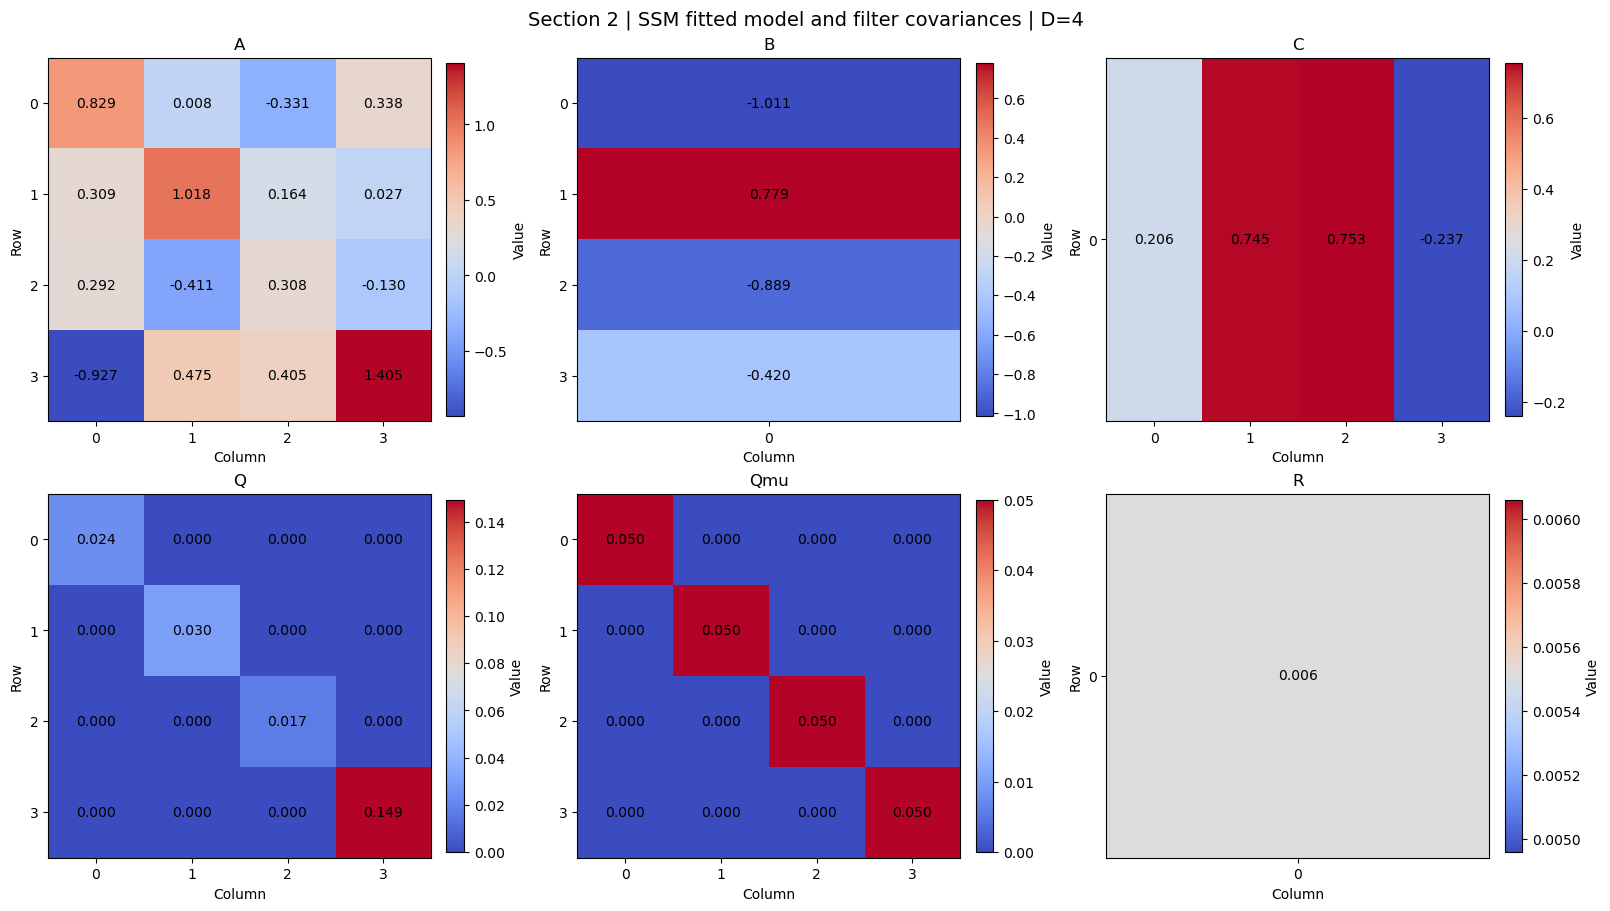

In [78]:
ssm_result = ssm_best_results[SSM_PLOT_D]
ssm_fitted_params = ssm_result["fitted_params"]
ssm_step_results = ssm_result["step_results"]
ssm_batch_df = ssm_result["batch_df"]

Q_matrix = np.asarray(ssm_result["Q_best"], dtype=float)
Qmu_matrix = np.asarray(ssm_result["Qmu_best"], dtype=float)
R_matrix = np.asarray(ssm_result["R_best"], dtype=float)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
plot_model_matrix_grid(np.asarray(ssm_fitted_params["A"], dtype=float), "A", ax=axes[0, 0])
plot_model_matrix_grid(np.asarray(ssm_fitted_params["B"], dtype=float), "B", ax=axes[0, 1])
plot_model_matrix_grid(np.asarray(ssm_fitted_params["C"], dtype=float), "C", ax=axes[0, 2])
plot_model_matrix_grid(Q_matrix, "Q", ax=axes[1, 0])
plot_model_matrix_grid(Qmu_matrix, "Qmu", ax=axes[1, 1])
plot_model_matrix_grid(R_matrix, "R", ax=axes[1, 2])
fig.suptitle(f"Section 2 | SSM fitted model and filter covariances | D={SSM_PLOT_D}", fontsize=14)
plt.show()

## Default-scale trial-average plots


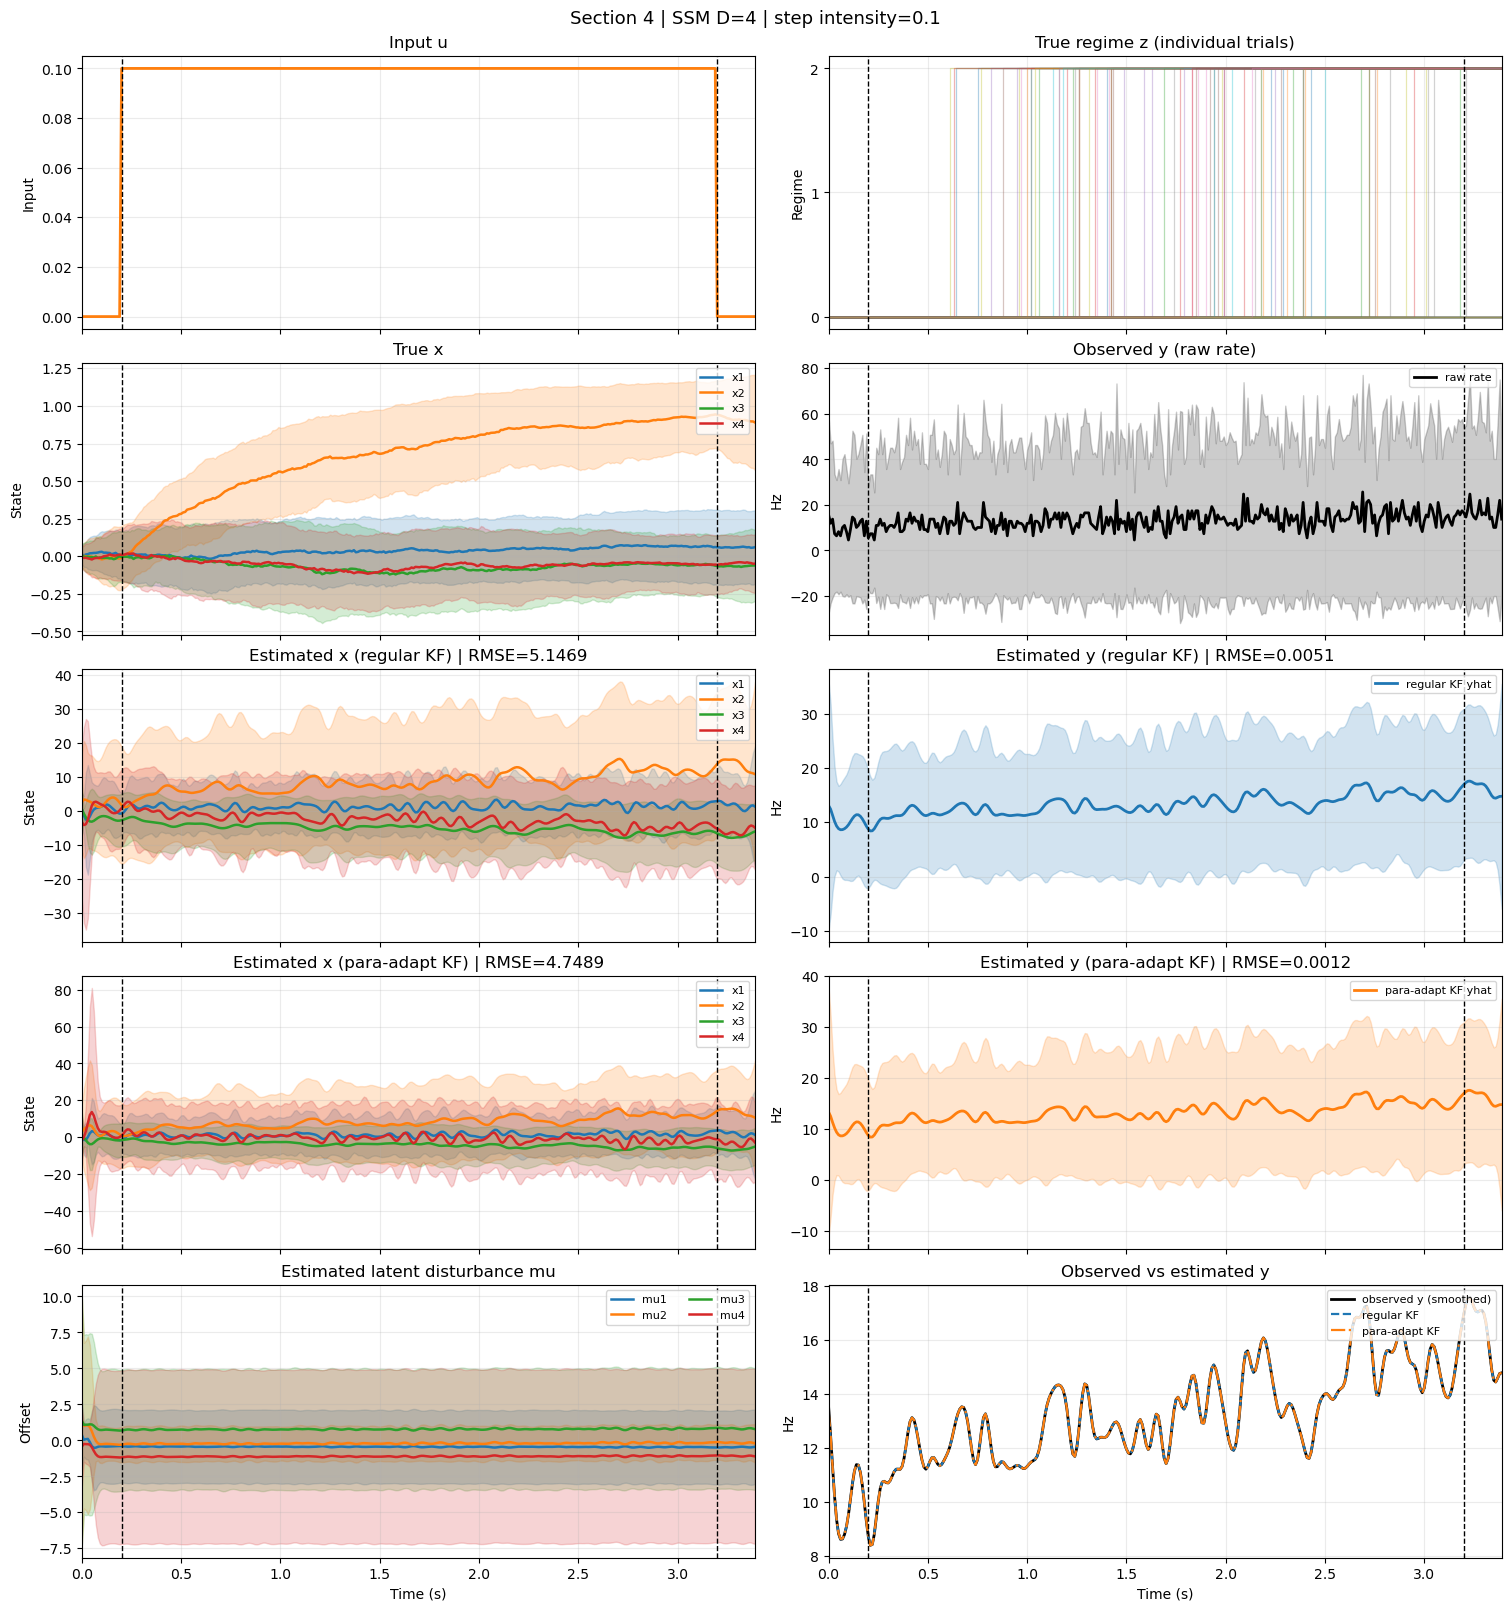

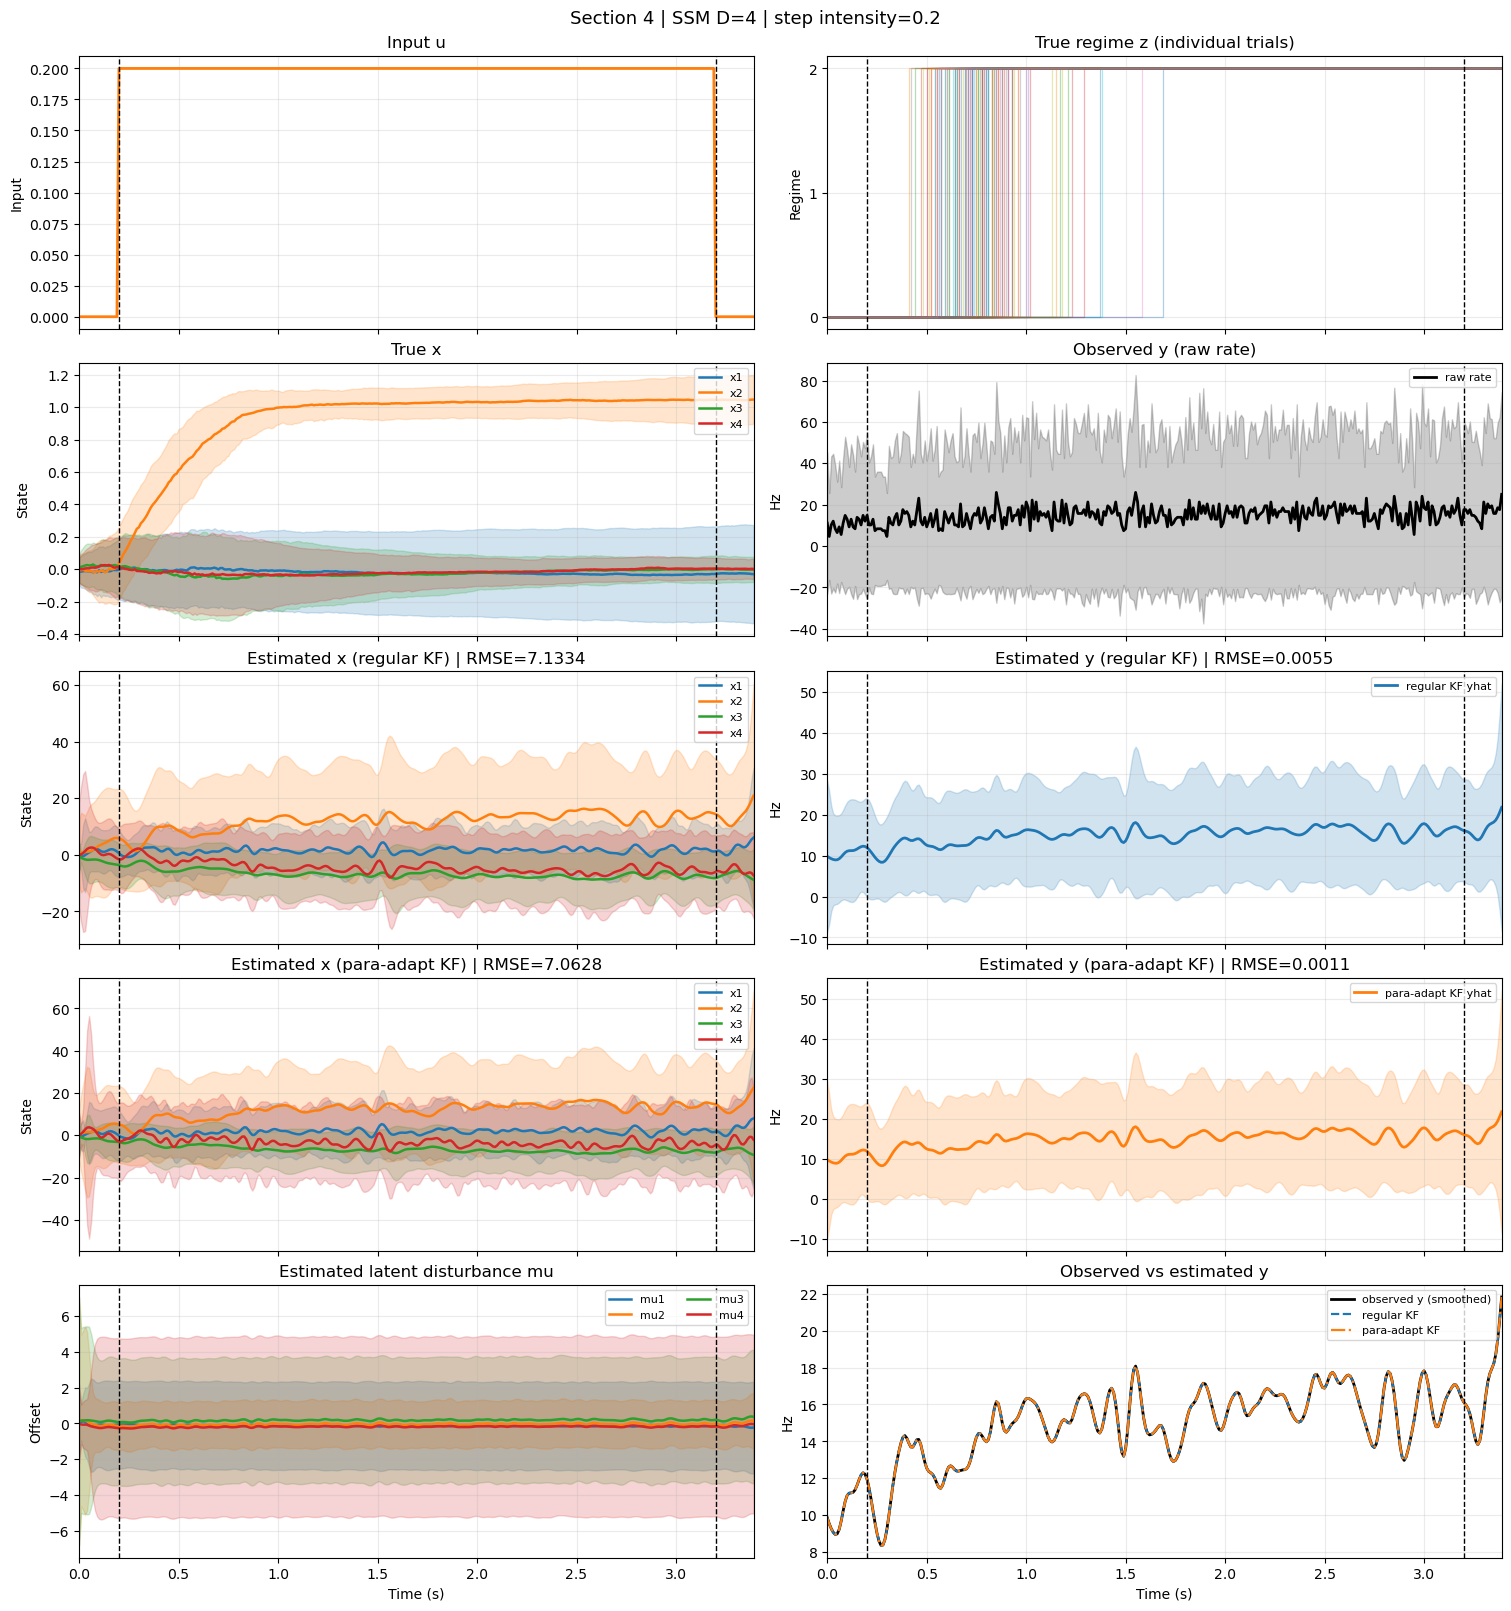

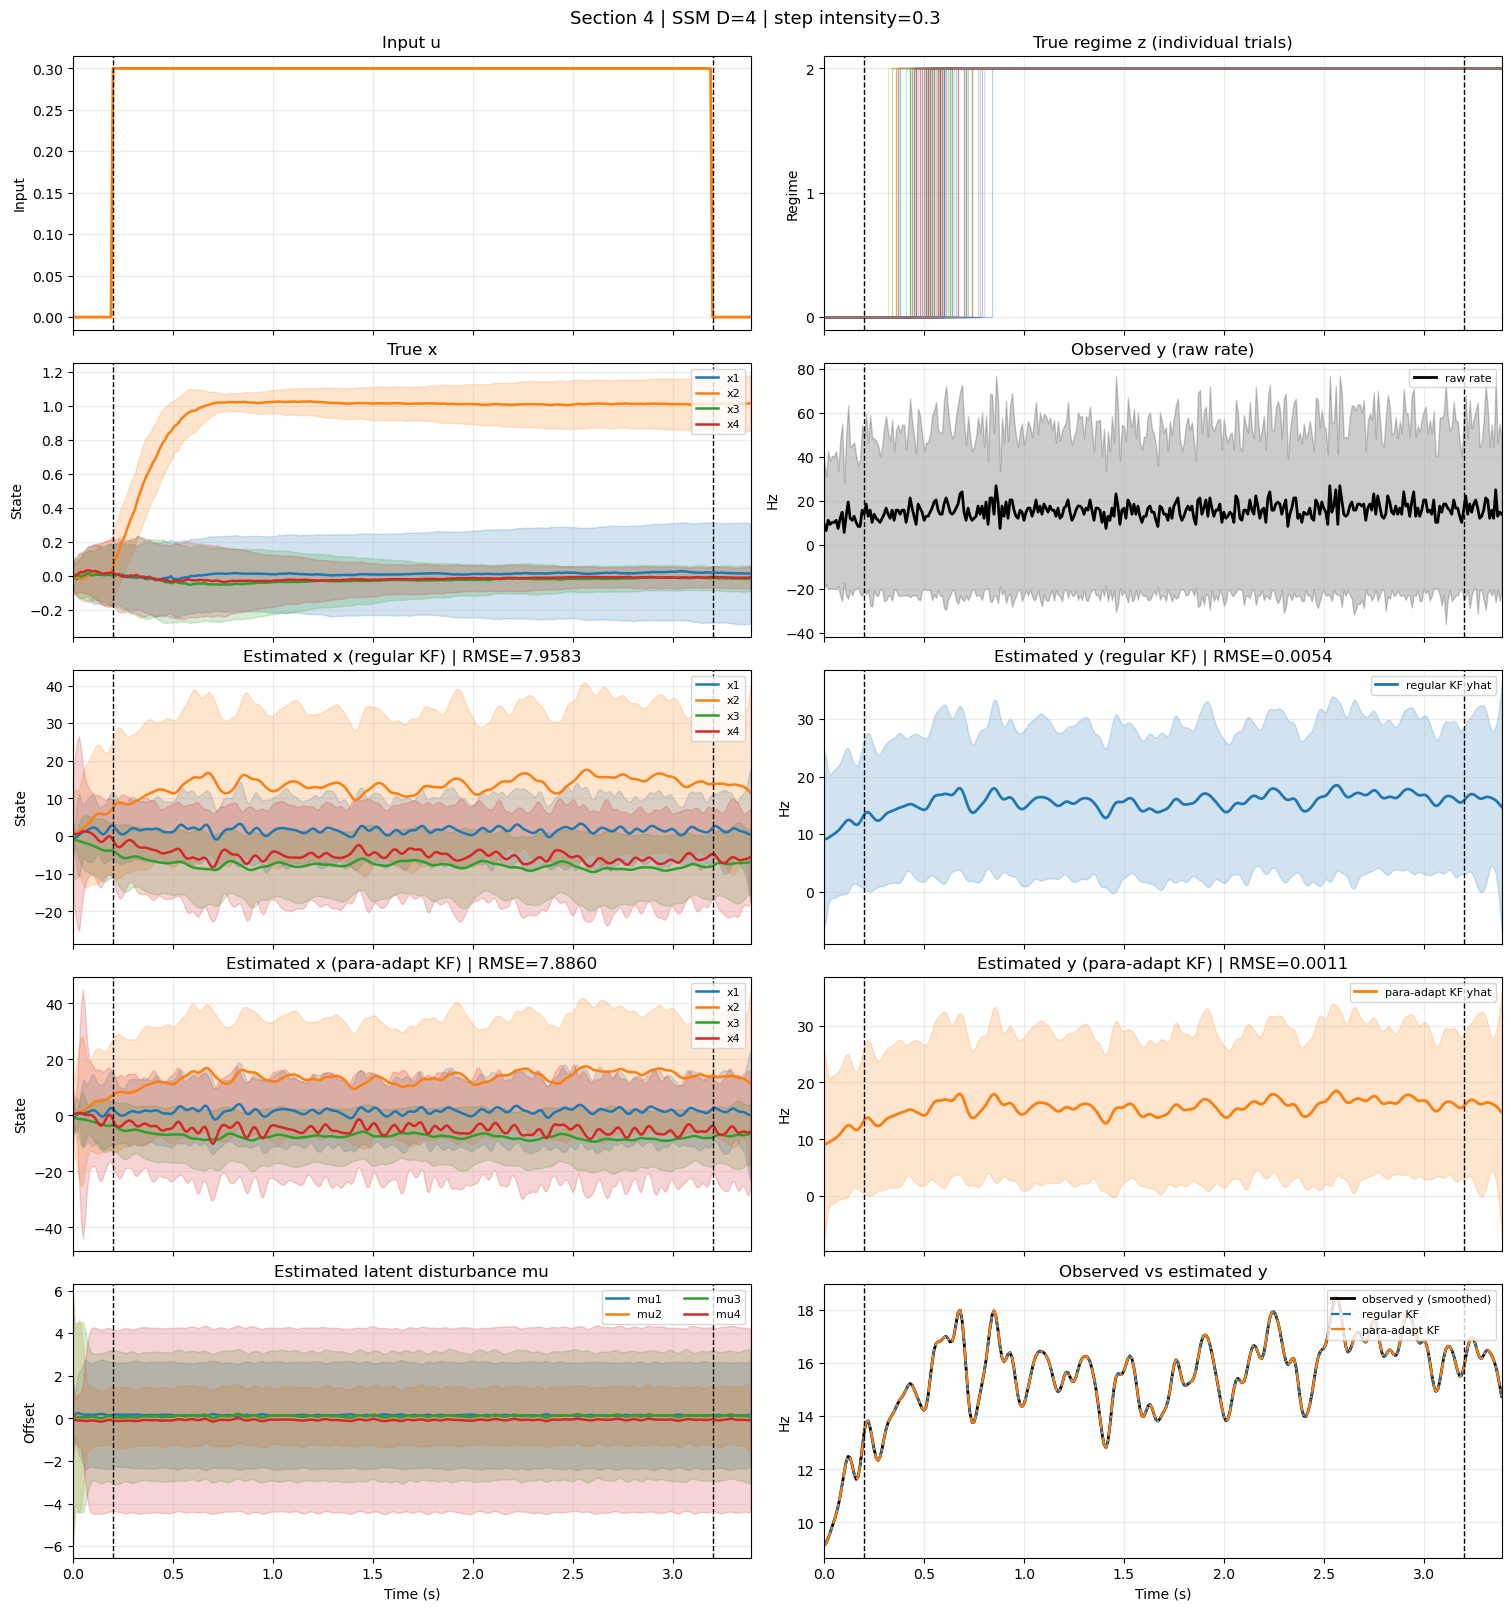

In [79]:
section4_intensity_order = sorted(float(level) for level in np.unique(np.round(light_intensity[STEP_TRIALS], 6)))
for level in section4_intensity_order:
    combo_results = [result for result in ssm_step_results if np.isclose(result["light_intensity"], level)]
    fig = plot_combo_trial_average_summary(combo_results)
    fig.suptitle(f"Section 4 | SSM D={SSM_PLOT_D} | step intensity={level:g}", fontsize=13)
    plt.show()

## Default-scale RMSE summary


C:\Users\jxiao85\AppData\Local\Temp\ipykernel_1464\1852552156.py:191: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  y_box = axes[0, 0].boxplot([batch_df["kf_y_rmse_stim"], batch_df["para_y_rmse_stim"]], patch_artist=True, labels=["Regular KF", "Para adapt KF"])
C:\Users\jxiao85\AppData\Local\Temp\ipykernel_1464\1852552156.py:222: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  x_box = axes[1, 0].boxplot([batch_df["kf_x_rmse_stim"], batch_df["para_x_rmse_stim"]], patch_artist=True, labels=["Regular KF", "Para adapt KF"])


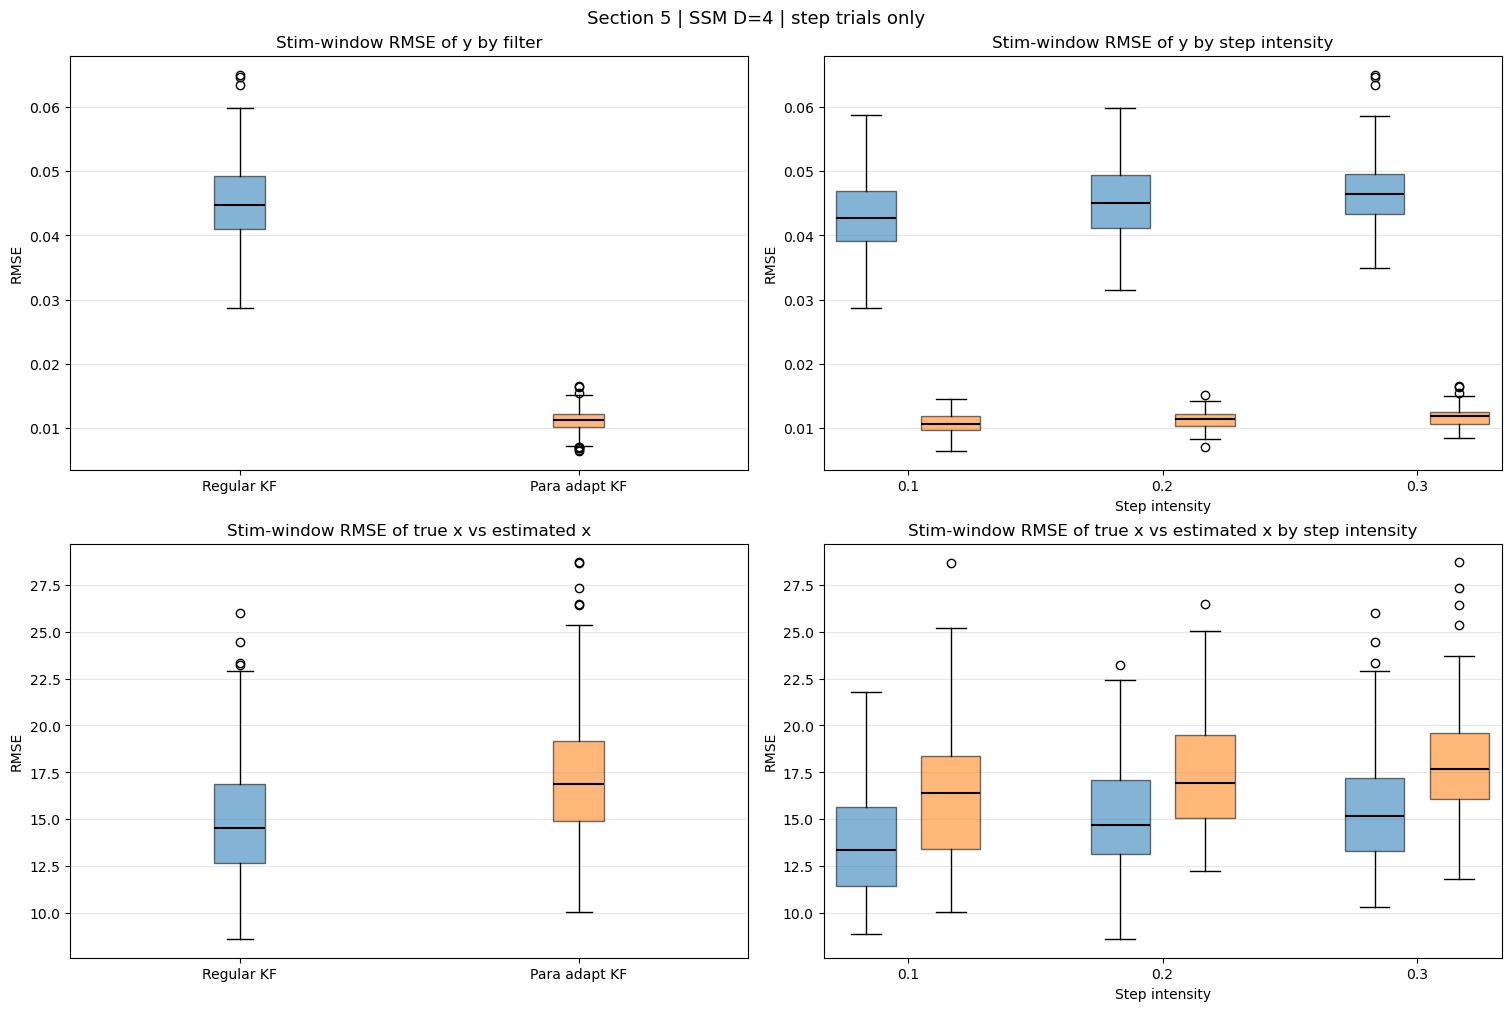

,trial_index,light_intensity,kf_y_rmse_stim,para_y_rmse_stim,kf_x_rmse_stim,para_x_rmse_stim
0,75,0.1,0.041139,0.009707,11.372705,24.893602
1,78,0.1,0.047132,0.012085,15.980607,16.852125
2,81,0.1,0.041998,0.009736,15.652985,17.467492
3,84,0.1,0.035551,0.008440,10.515062,11.709821
4,87,0.1,0.046160,0.010846,19.096518,20.750212


In [80]:
section5_fig, section5_filtered_df = plot_group_rmse_stats(ssm_batch_df)
section5_fig.suptitle(f"Section 5 | SSM D={SSM_PLOT_D} | step trials only", fontsize=13)
plt.show()
display(section5_filtered_df.head())

## Manual-tuned filter parameters


In [81]:
# pick one fitted model first
fitted_params = ssm_best_results[FITTED_LATENT_DIM]["fitted_params"]

# manual anti-cheating / Bolus-style biasing knobs
MANUAL_Q_SCALE = 0.00000005
MANUAL_QMU_SCALE = 0.00000005
MANUAL_R_SCALE = 1.0

Q_matrix = MANUAL_Q_SCALE * np.asarray(fitted_params["Q_fit_base"], dtype=float)
R_matrix = MANUAL_R_SCALE * np.asarray(fitted_params["R_fit"], dtype=float)
Qmu_matrix = MANUAL_QMU_SCALE * np.eye(int(fitted_params["D"]), dtype=float)

print("Manual Q diag:", np.diag(Q_matrix))
print("Manual R diag:", np.diag(R_matrix))
print("Manual Qmu diag:", np.diag(Qmu_matrix))

manual_step_results = build_step_trial_results(
    STEP_TRIALS,
    fitted_params=fitted_params,
    Q_matrix=Q_matrix,
    R_matrix=R_matrix,
    init_cov_scale=INIT_COV_SCALE,
    Qmu_matrix=Qmu_matrix,
)
manual_batch_df, manual_batch_df_av = build_batch_tables(manual_step_results)

print("Mean KF y RMSE:", manual_batch_df["kf_y_rmse_stim"].mean())
print("Mean para y RMSE:", manual_batch_df["para_y_rmse_stim"].mean())
print("Mean KF x RMSE:", manual_batch_df["kf_x_rmse_stim"].mean())
print("Mean para x RMSE:", manual_batch_df["para_x_rmse_stim"].mean())

Manual Q diag: [2.35527133e-08 3.04038222e-08 1.69257395e-08 1.49314018e-07]
Manual R diag: [0.00550942]
Manual Qmu diag: [5.e-08 5.e-08 5.e-08 5.e-08]
Mean KF y RMSE: 13.045903572307468
Mean para y RMSE: 9.571790193058671
Mean KF x RMSE: 5.860565023602117
Mean para x RMSE: 10.865923011741721


## Manual-tuned model matrices


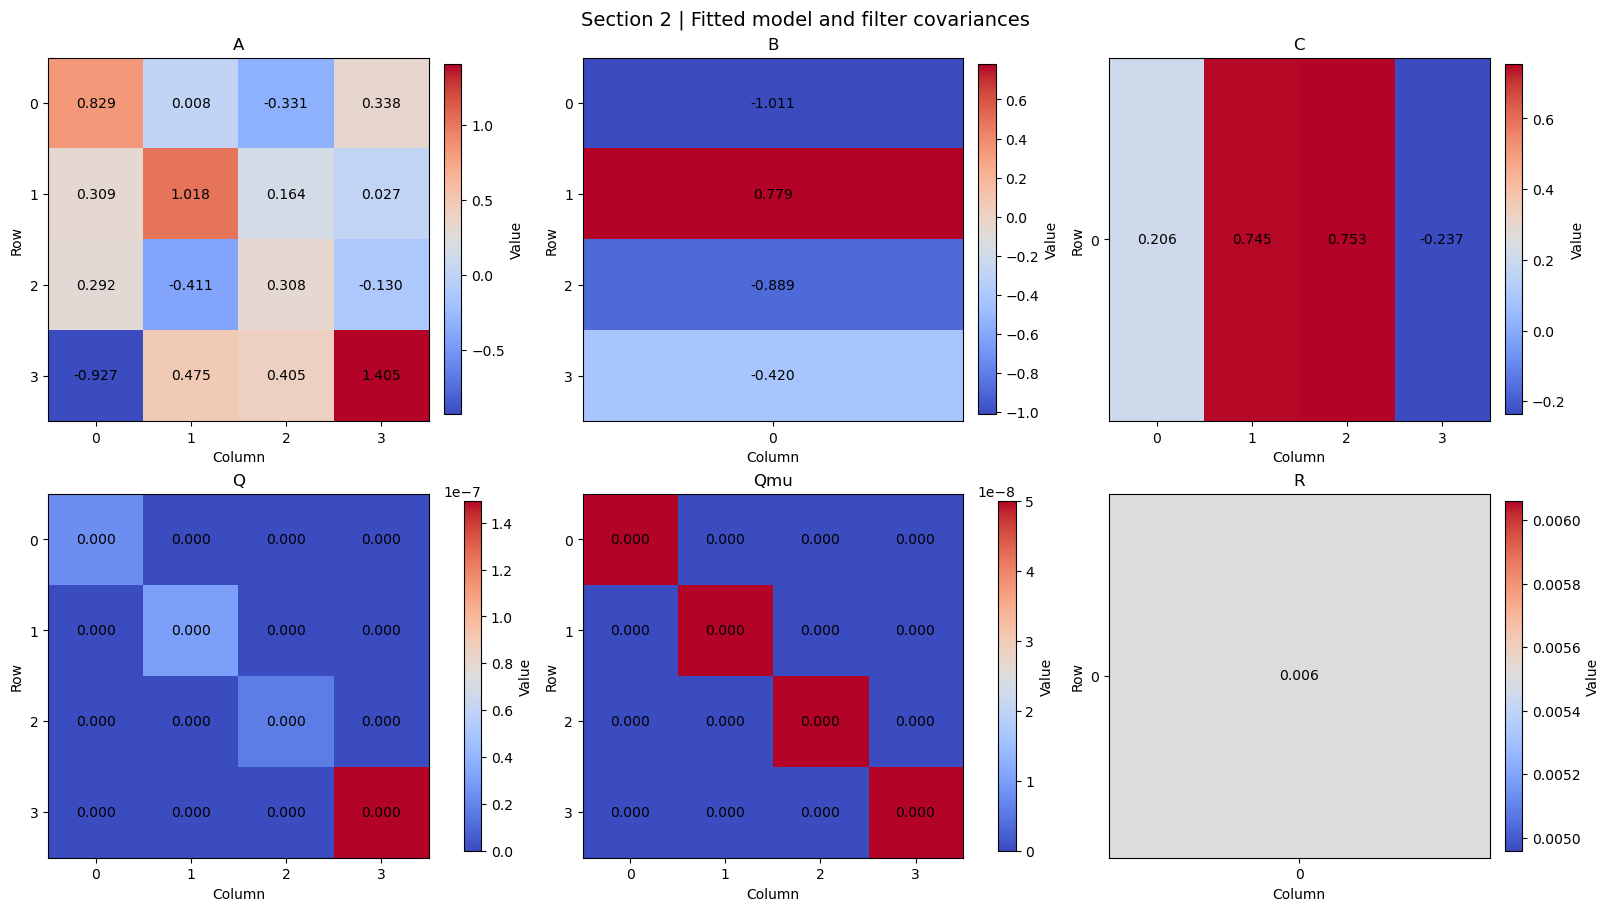

In [82]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
plot_model_matrix_grid(np.asarray(fitted_params["A"], dtype=float), "A", ax=axes[0, 0])
plot_model_matrix_grid(np.asarray(fitted_params["B"], dtype=float), "B", ax=axes[0, 1])
plot_model_matrix_grid(np.asarray(fitted_params["C"], dtype=float), "C", ax=axes[0, 2])
plot_model_matrix_grid(np.asarray(Q_matrix, dtype=float), "Q", ax=axes[1, 0])
plot_model_matrix_grid(np.asarray(Qmu_matrix, dtype=float), "Qmu", ax=axes[1, 1])
plot_model_matrix_grid(np.asarray(R_matrix, dtype=float), "R", ax=axes[1, 2])
fig.suptitle("Section 2 | Fitted model and filter covariances", fontsize=14)
plt.show()

## Manual-tuned trial-average plots


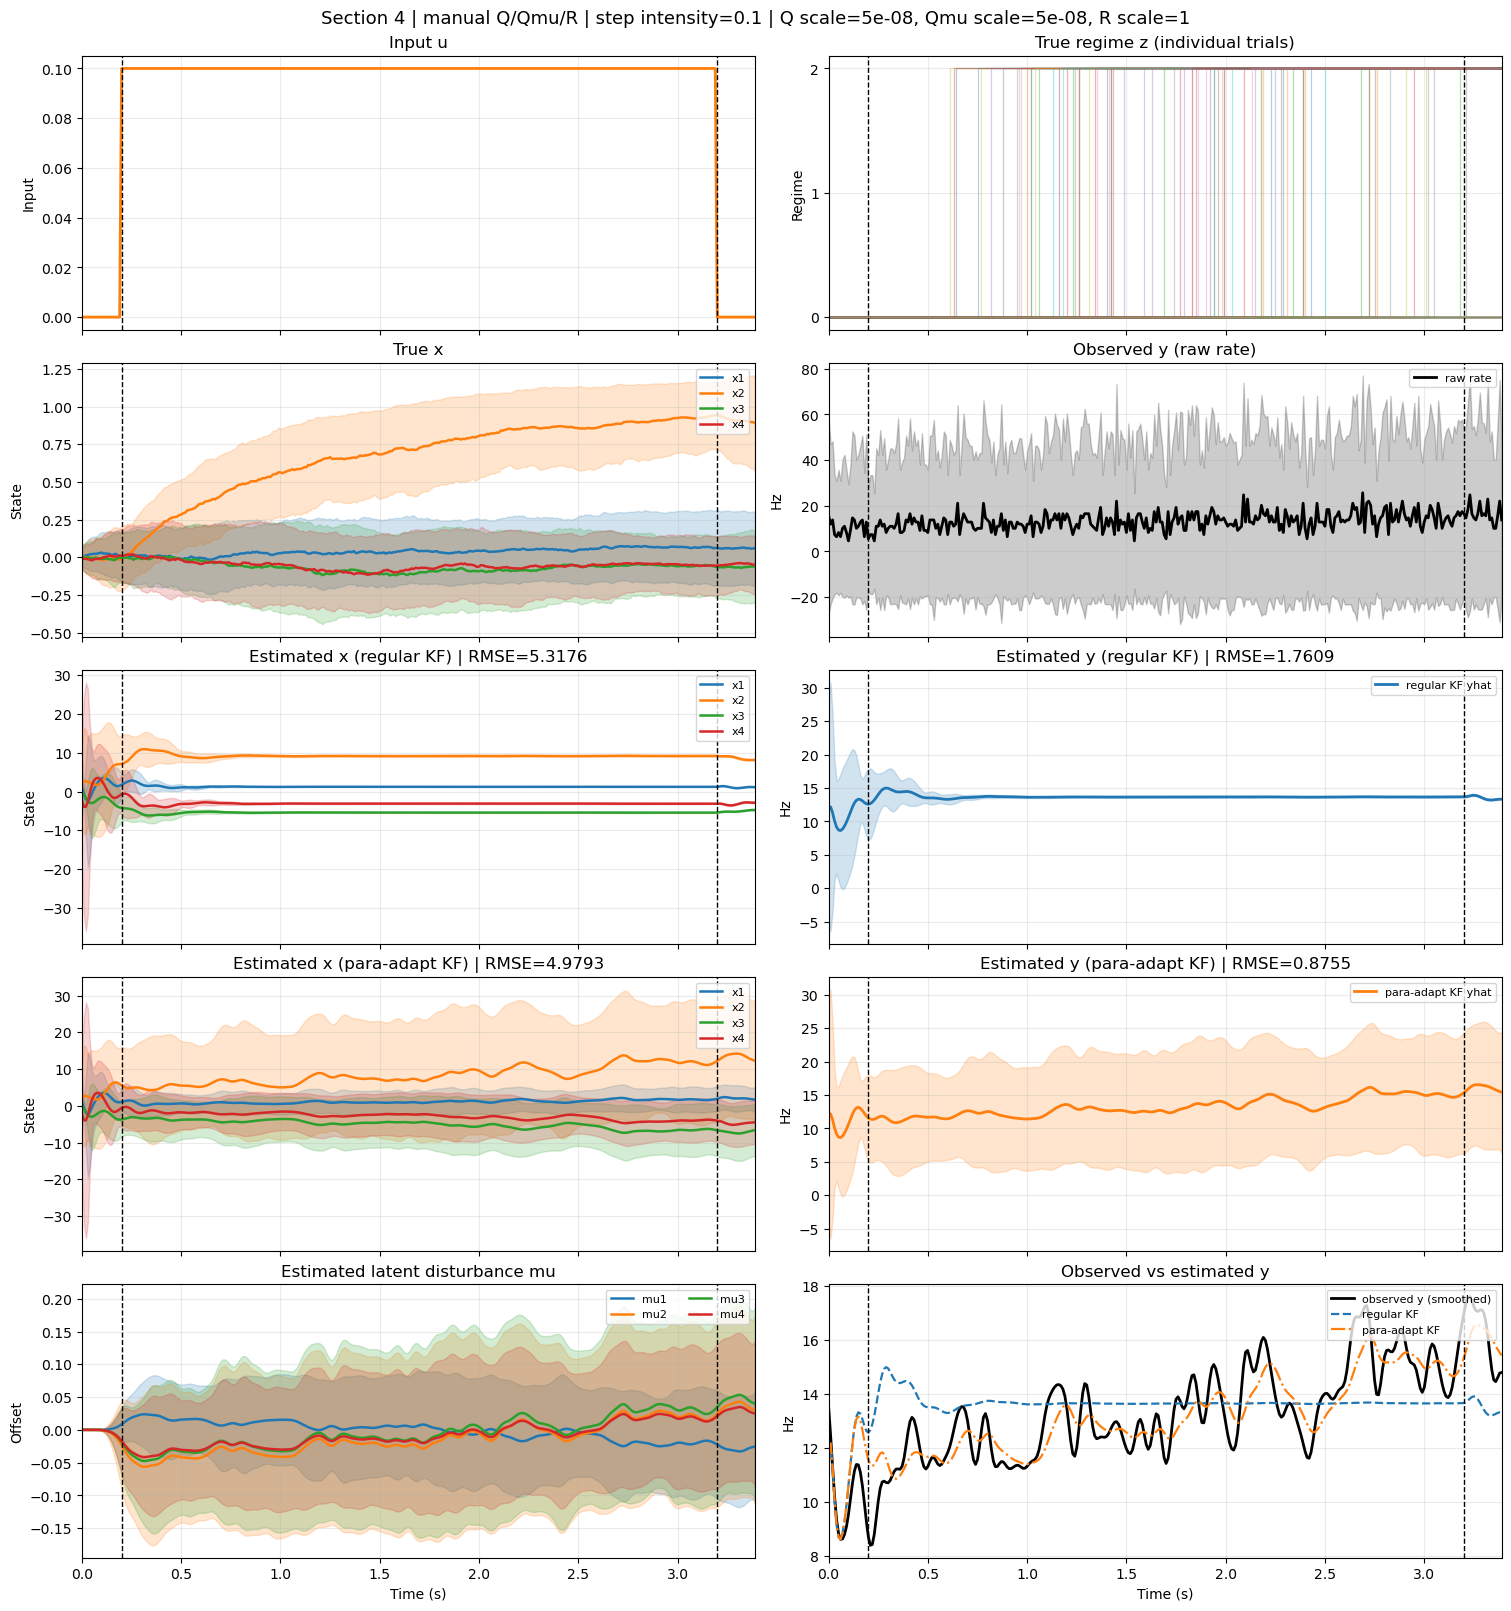

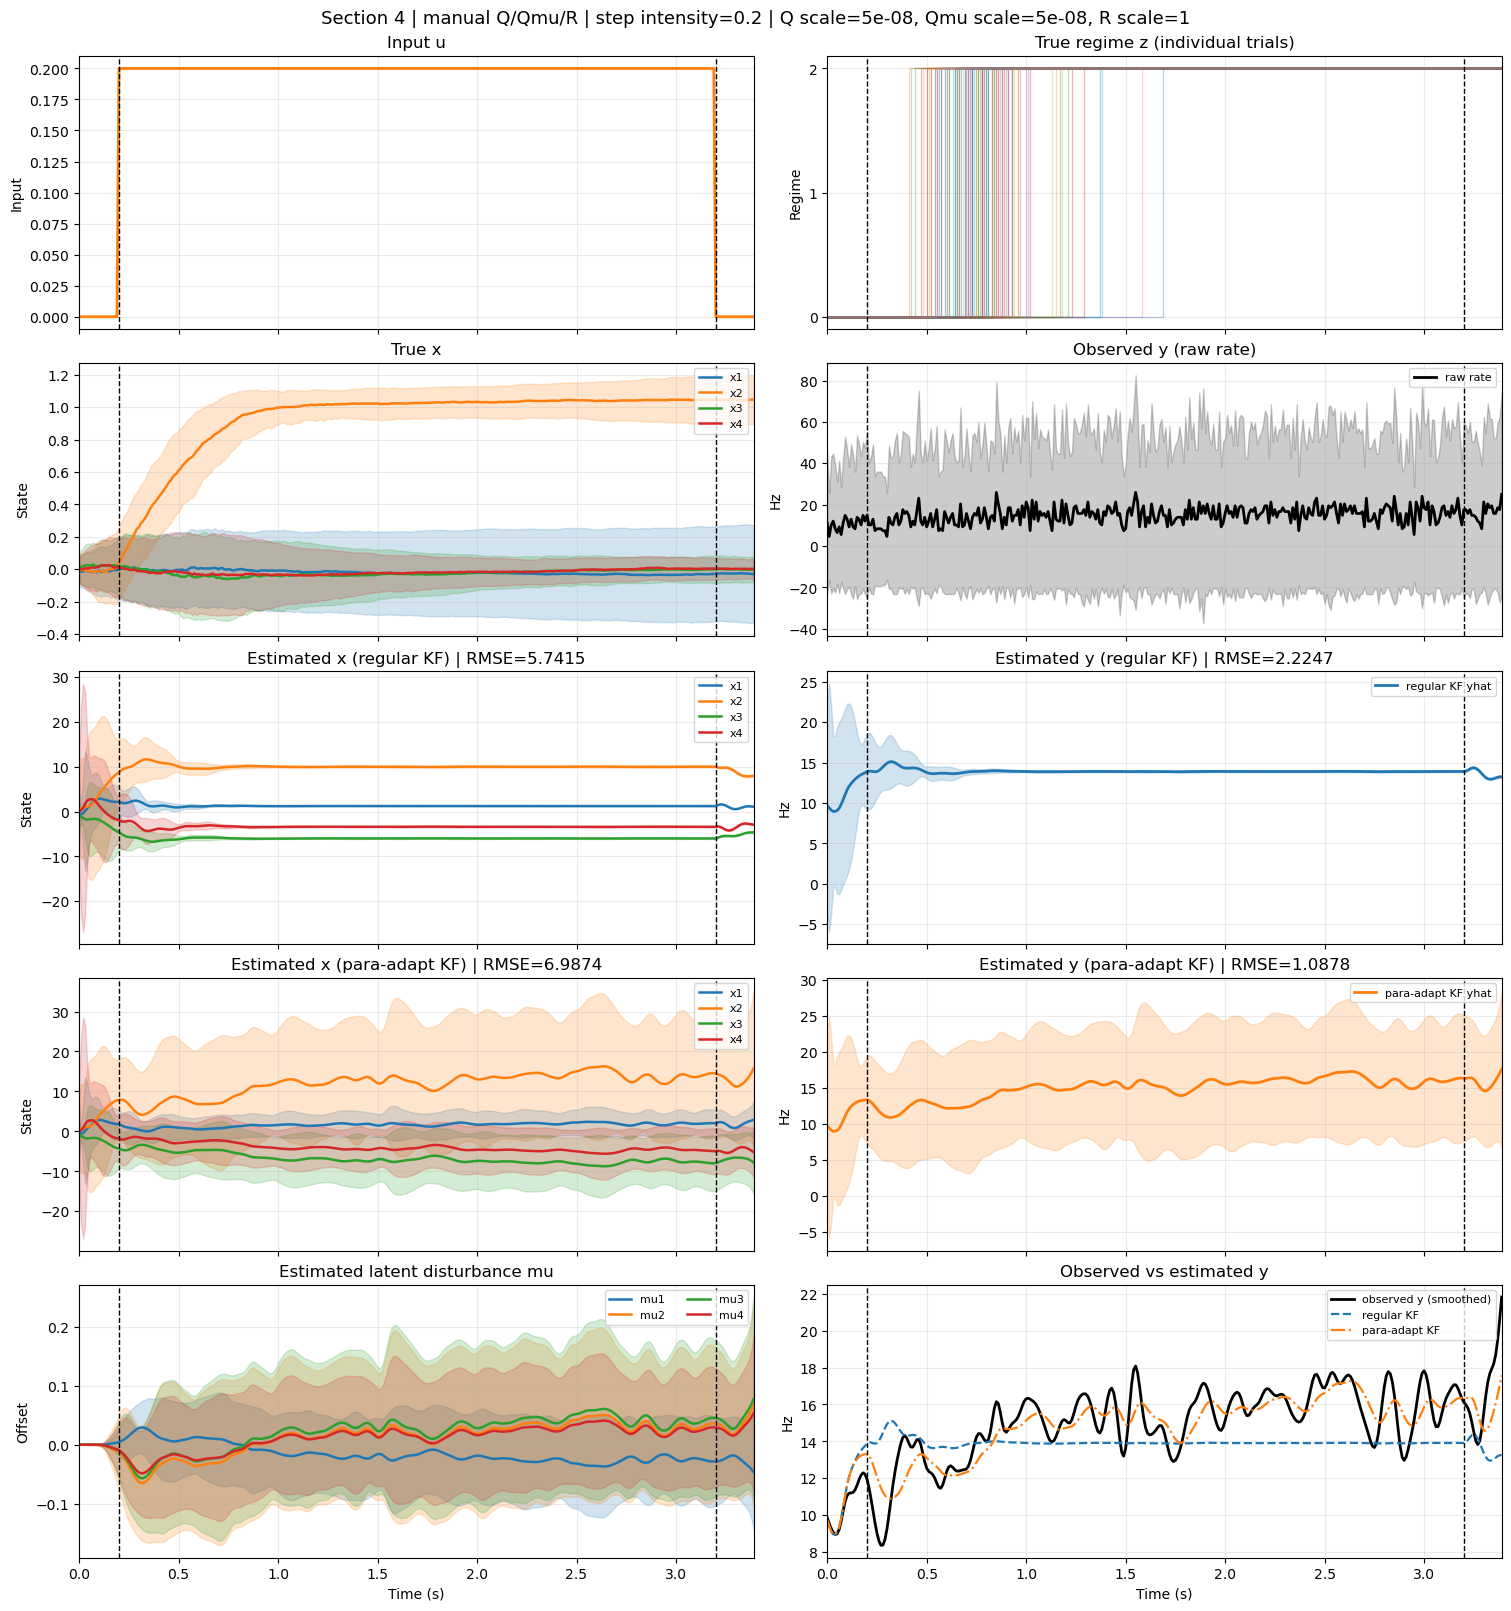

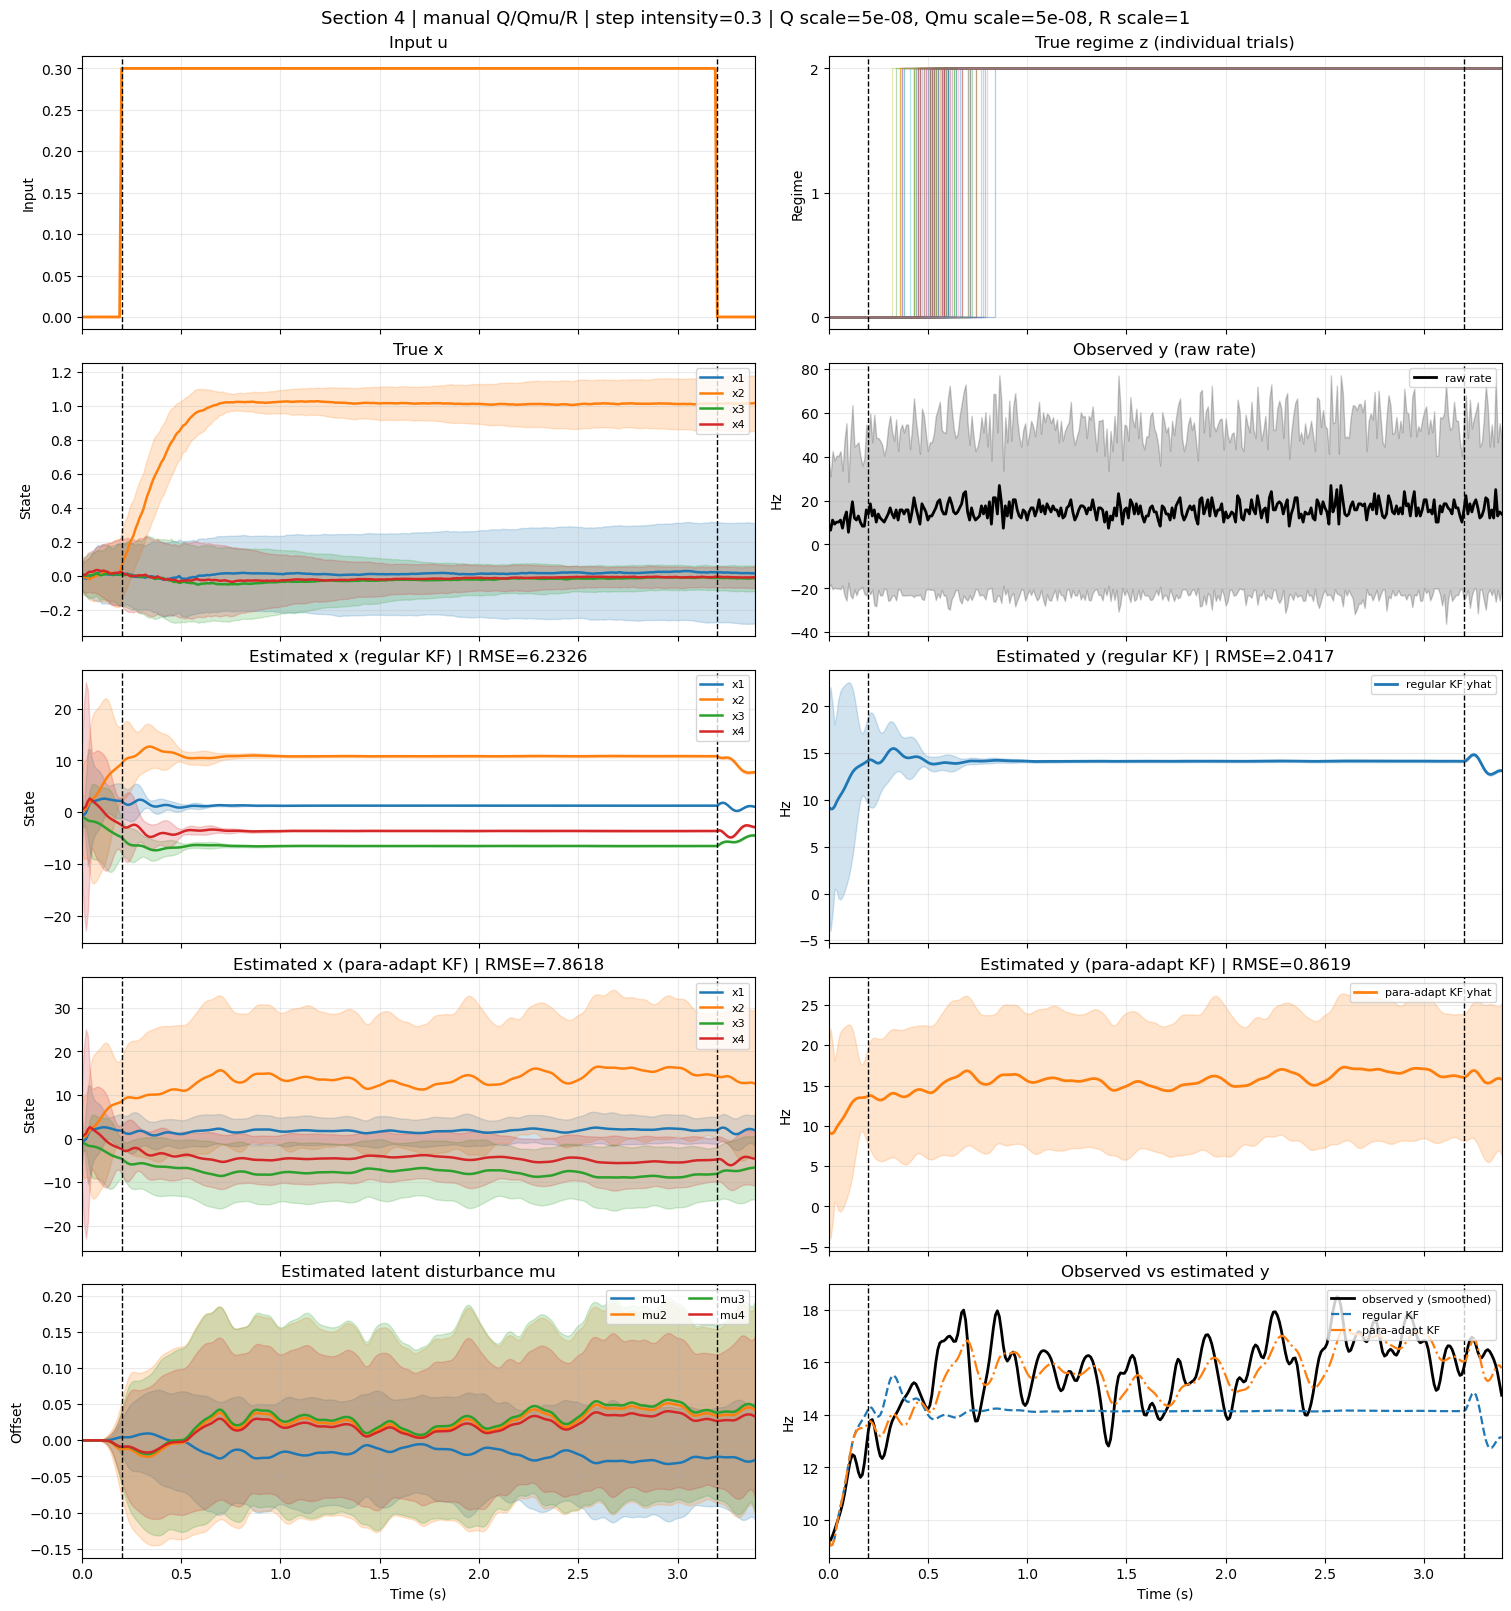

In [83]:
for level in section4_intensity_order:
    combo_results = [result for result in manual_step_results if np.isclose(result["light_intensity"], level)]
    fig = plot_combo_trial_average_summary(combo_results)
    fig.suptitle(
        f"Section 4 | manual Q/Qmu/R"
        f" | step intensity={level:g}"
        f" | Q scale={MANUAL_Q_SCALE:g}, Qmu scale={MANUAL_QMU_SCALE:g}, R scale={MANUAL_R_SCALE:g}",
        fontsize=13,
    )
    plt.show()

## Manual-tuned RMSE summary


C:\Users\jxiao85\AppData\Local\Temp\ipykernel_1464\1852552156.py:191: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  y_box = axes[0, 0].boxplot([batch_df["kf_y_rmse_stim"], batch_df["para_y_rmse_stim"]], patch_artist=True, labels=["Regular KF", "Para adapt KF"])
C:\Users\jxiao85\AppData\Local\Temp\ipykernel_1464\1852552156.py:222: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  x_box = axes[1, 0].boxplot([batch_df["kf_x_rmse_stim"], batch_df["para_x_rmse_stim"]], patch_artist=True, labels=["Regular KF", "Para adapt KF"])


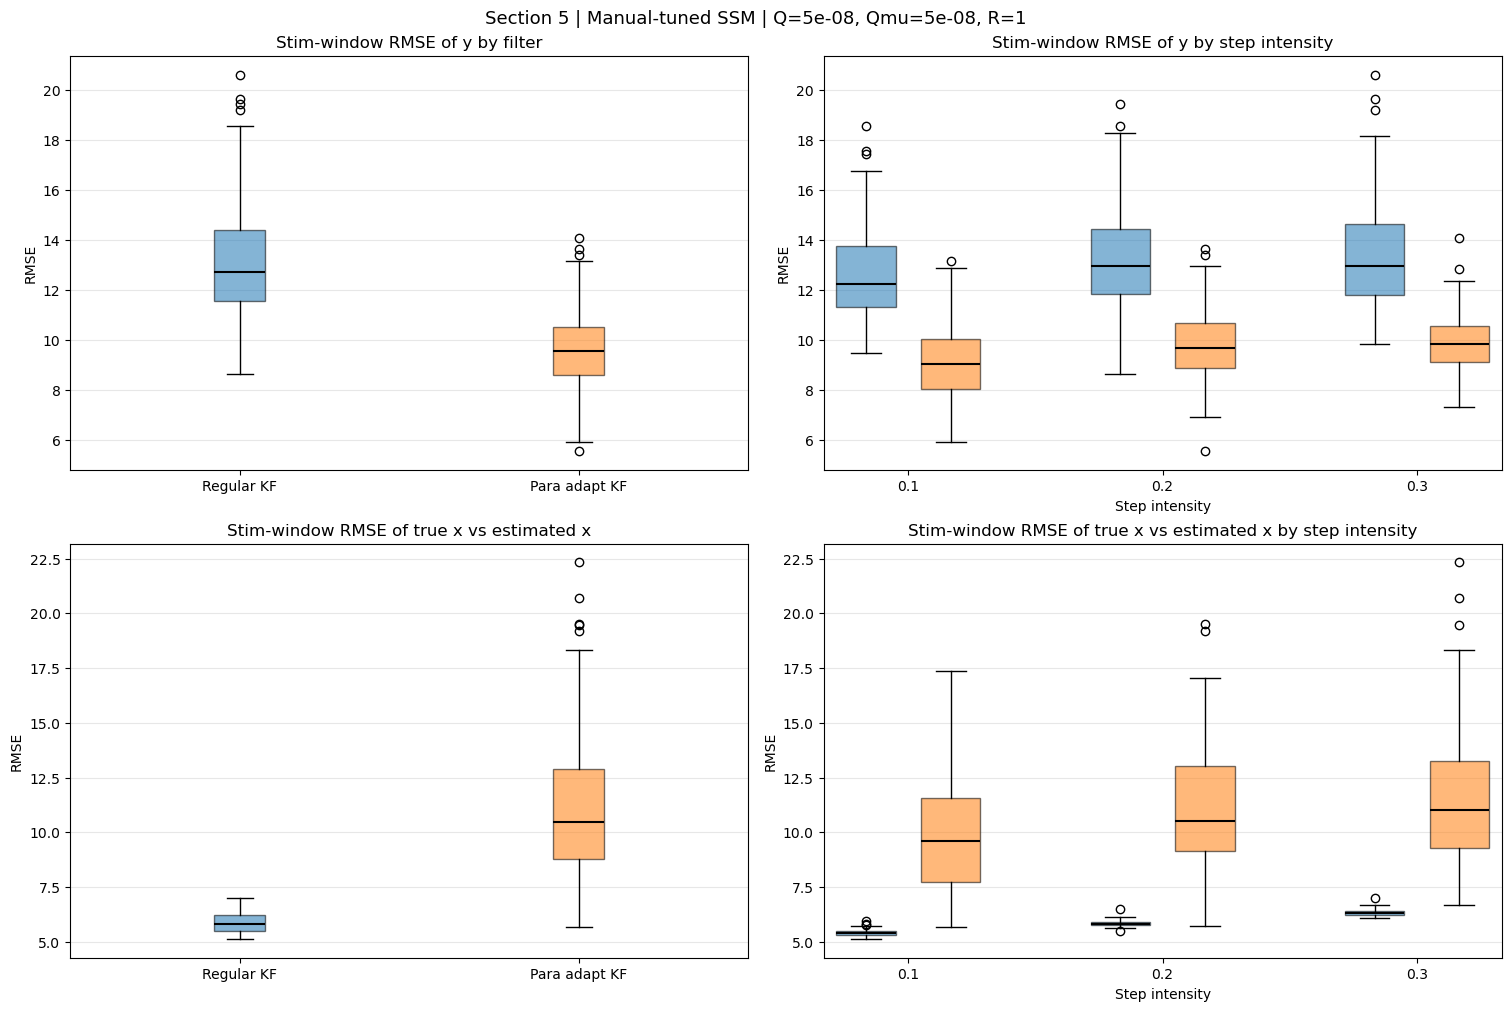

,trial_index,light_intensity,kf_y_rmse_stim,para_y_rmse_stim,kf_x_rmse_stim,para_x_rmse_stim
0,75,0.1,11.623418,8.597777,5.256001,7.538395
1,78,0.1,12.531041,9.175992,5.506947,12.927653
2,81,0.1,14.645501,9.750580,5.456705,11.184351
3,84,0.1,11.163045,7.826418,5.333634,6.593134
4,87,0.1,16.117053,10.127925,5.444029,15.487144


Trials in grouped stats: 325
Mean KF y RMSE: 13.045903572307468
Mean para y RMSE: 9.571790193058671
Mean KF x RMSE: 5.860565023602117
Mean para x RMSE: 10.865923011741721


In [84]:
manual_section5_fig, manual_section5_filtered_df = plot_group_rmse_stats(manual_batch_df)
manual_section5_fig.suptitle(
    f"Section 5 | Manual-tuned SSM"
    f" | Q={MANUAL_Q_SCALE:g}, Qmu={MANUAL_QMU_SCALE:g}, R={MANUAL_R_SCALE:g}",
    fontsize=13,
)
plt.show()
display(manual_section5_filtered_df.head())
print("Trials in grouped stats:", len(manual_section5_filtered_df))
print("Mean KF y RMSE:", manual_section5_filtered_df["kf_y_rmse_stim"].mean())
print("Mean para y RMSE:", manual_section5_filtered_df["para_y_rmse_stim"].mean())
print("Mean KF x RMSE:", manual_section5_filtered_df["kf_x_rmse_stim"].mean())
print("Mean para x RMSE:", manual_section5_filtered_df["para_x_rmse_stim"].mean())

## Map estimated x to true x with a 4x4 state transform

Find a matrix T such that x_bar = T @ x_estimated is closest to x_true.

Regular KF T matrix:


,xest1,xest2,xest3,xest4
xbar1,0.000307,-0.000420,-0.001160,-0.002005
xbar2,0.158887,-0.174873,-0.372880,-0.051192
xbar3,-0.018079,0.006301,0.013752,-0.002274
xbar4,-0.005822,-0.005881,-0.001839,-0.007795


Para-adaptive KF T matrix:


,xest1,xest2,xest3,xest4
xbar1,-0.025513,0.018387,0.015339,0.015540
xbar2,0.381595,-0.354801,-0.605352,-0.082218
xbar3,-0.098791,0.074190,0.082370,0.048471
xbar4,-0.076259,0.058212,0.065783,0.037068


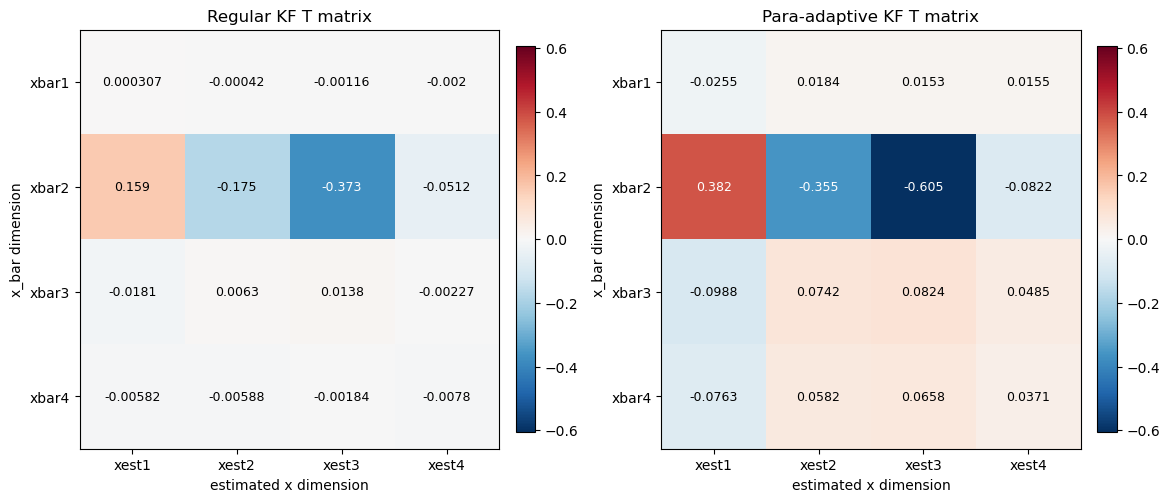

,filter,x_dim,raw_rmse_test,transformed_rmse_test,rmse_delta_test
0,Regular KF,1,1.417745,0.232097,1.185648
1,Regular KF,2,9.322299,0.303703,9.018596
2,Regular KF,3,6.005096,0.200982,5.804113
3,Regular KF,4,3.517031,0.179058,3.337973
4,Para-adaptive KF,1,3.494050,0.232904,3.261146
5,Para-adaptive KF,2,18.230881,0.320449,17.910432
6,Para-adaptive KF,3,9.148243,0.195183,8.953060
7,Para-adaptive KF,4,6.655286,0.174034,6.481252


Training trials: [ 76  77  78  79  81  82  83  84  86  87  88  89  91  92  93  94  96  97
  98  99 101 102 103 104 106 107 108 109 111 112 113 114 116 117 118 119
 121 122 123 124 126 127 128 129 131 132 133 134 136 137 138 139 141 142
 143 144 146 147 148 149 151 152 153 154 156 157 158 159 161 162 163 164
 166 167 168 169 171 172 173 174 176 177 178 179 181 182 183 184 186 187
 188 189 191 192 193 194 196 197 198 199 201 202 203 204 206 207 208 209
 211 212 213 214 216 217 218 219 221 222 223 224 226 227 228 229 231 232
 233 234 236 237 238 239 241 242 243 244 246 247 248 249 251 252 253 254
 256 257 258 259 261 262 263 264 266 267 268 269 271 272 273 274 276 277
 278 279 281 282 283 284 286 287 288 289 291 292 293 294 296 297 298 299
 301 302 303 304 306 307 308 309 311 312 313 314 316 317 318 319 321 322
 323 324 326 327 328 329 331 332 333 334 336 337 338 339 341 342 343 344
 346 347 348 349 351 352 353 354 356 357 358 359 361 362 363 364 366 367
 368 369 371 372 373 374 376 377 3

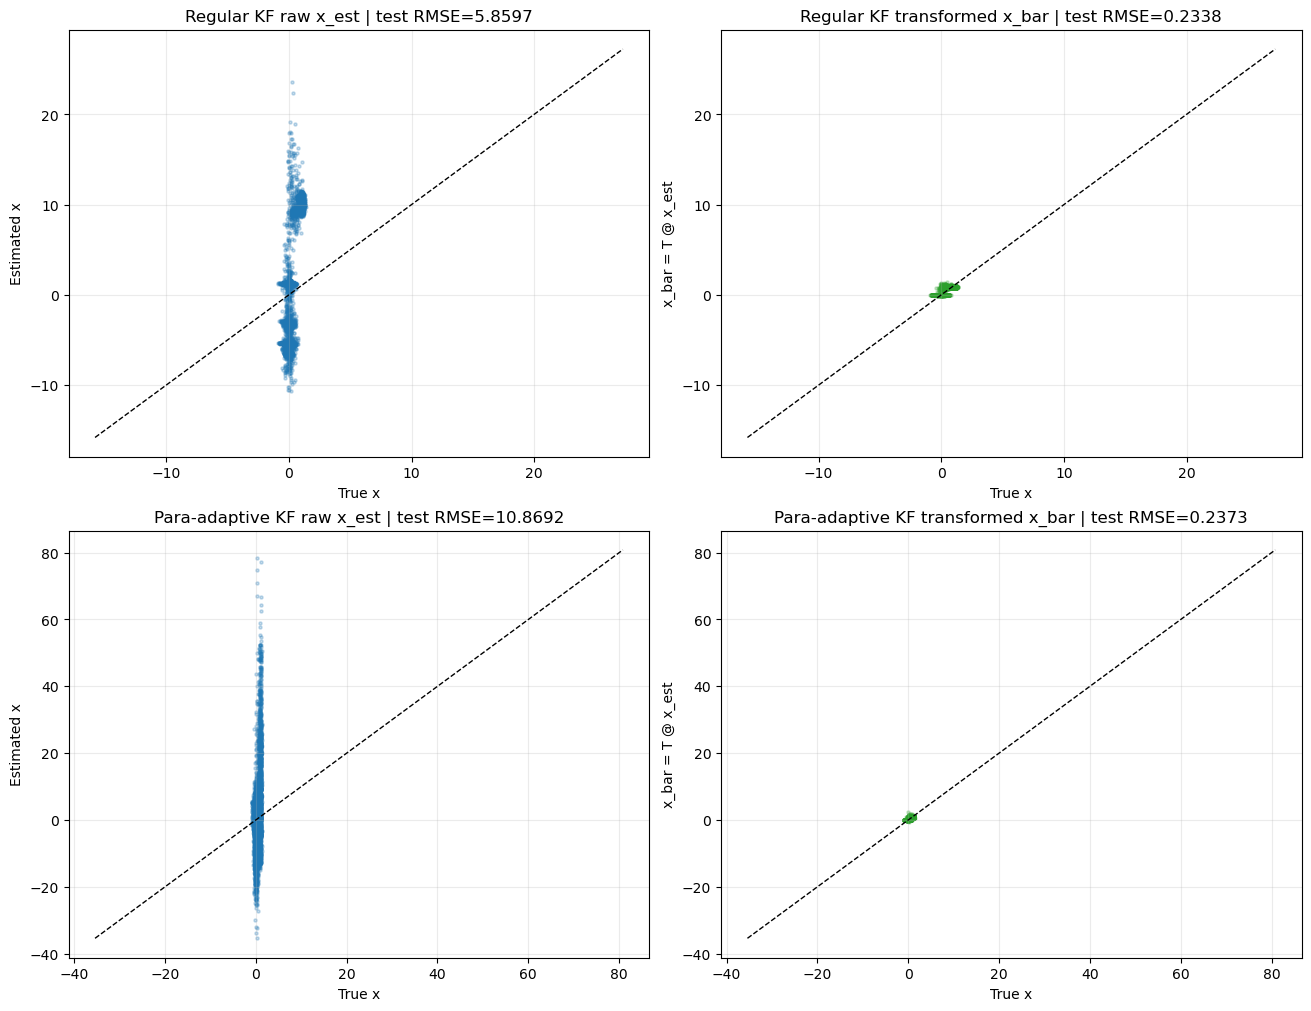

Held-out test trials selected for time-series plots:


,trial_index,light_intensity,true_x_abs_max,true_x_std
0,135.0,0.1,1.306021,0.453545
1,100.0,0.2,1.410188,0.486481
2,350.0,0.3,1.293309,0.514896


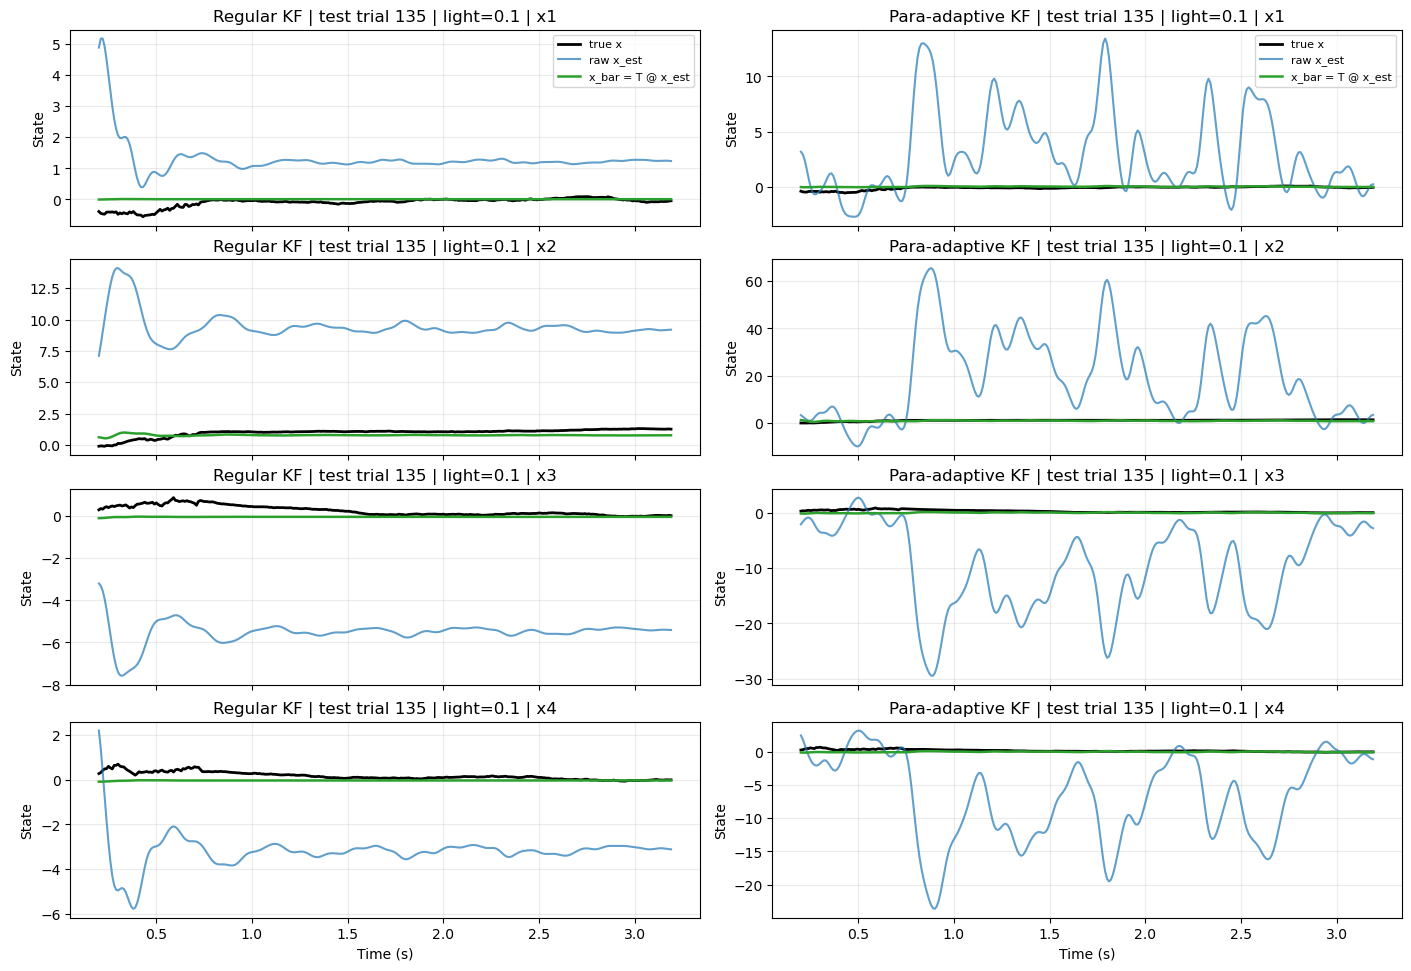

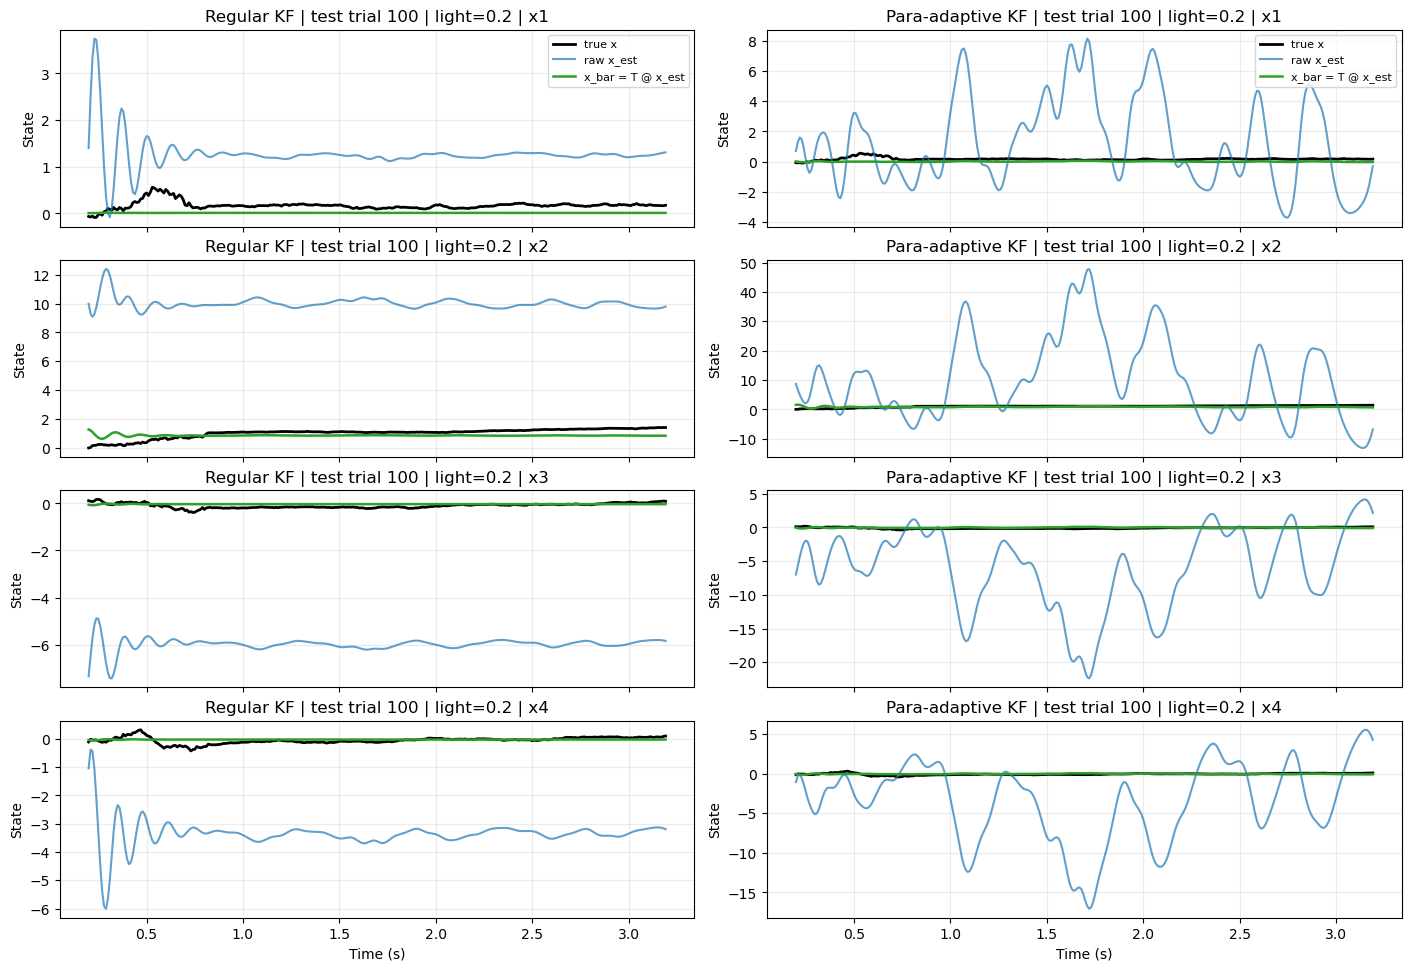

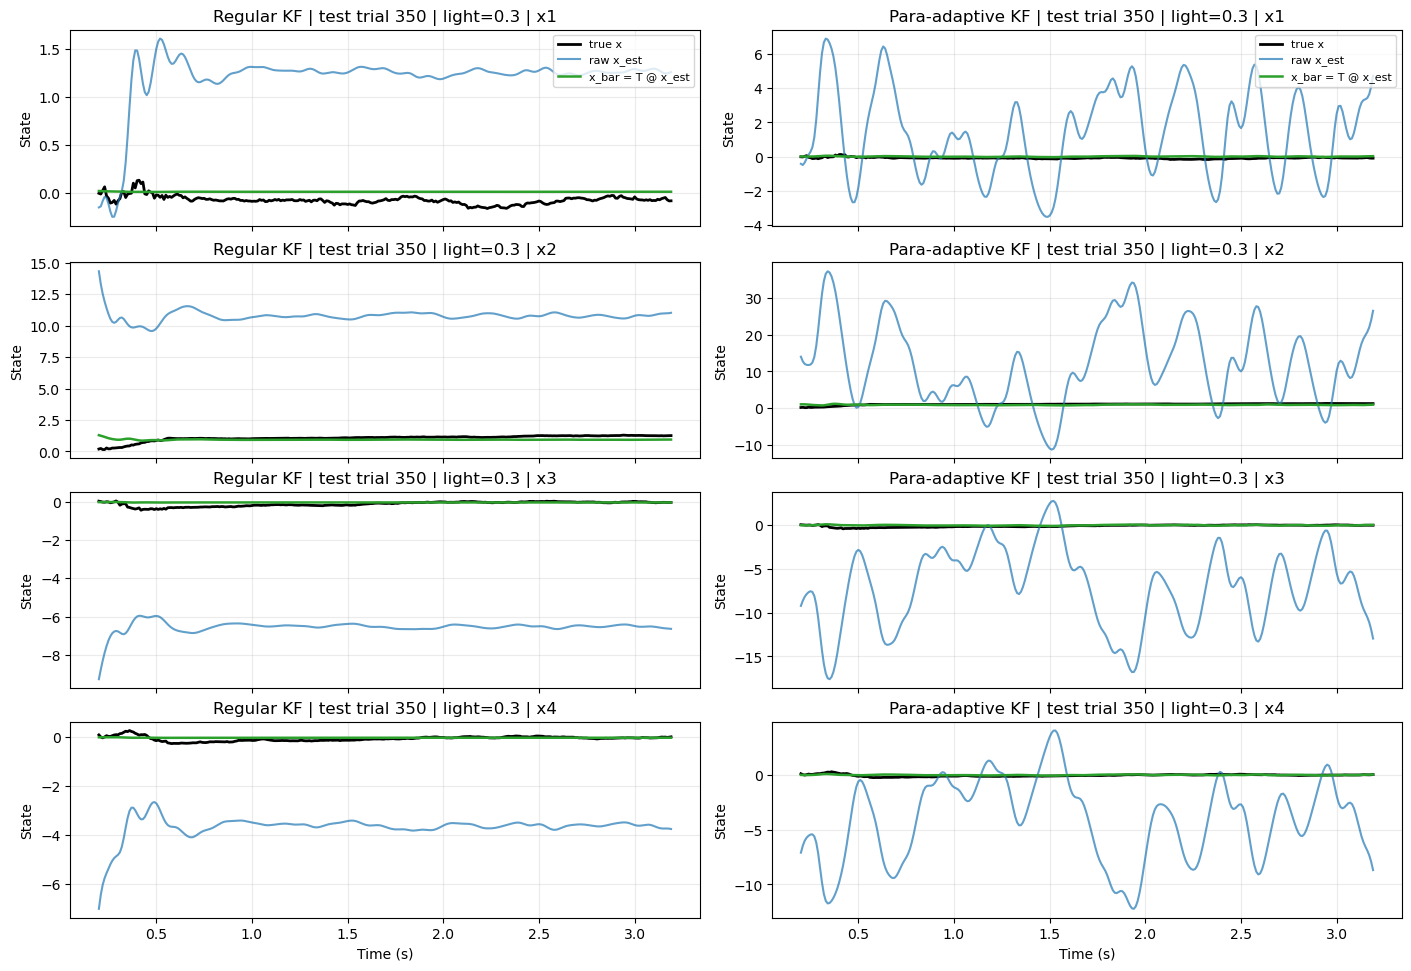

In [85]:
# Fit a 4x4 state-basis transform T so x_bar = T @ x_estimated is close to x_true.
# This is a no-intercept linear transform, matching the requested form.
TRANSFORM_STEP_RESULTS = manual_step_results if "manual_step_results" in globals() else ssm_step_results
TRANSFORM_USE_STIM_ONLY = True
TRANSFORM_TEST_EVERY_N_TRIALS = 5
TRANSFORM_EXAMPLE_LIGHT_INTENSITIES = [0.1, 0.2, 0.3]
TRANSFORM_TRUE_X_ACTIVE_TOL = 1e-8


def _stack_transform_arrays(step_results, estimate_key, use_stim_only=True):
    x_true_chunks = []
    x_est_chunks = []
    trial_chunks = []
    light_chunks = []
    time_chunks = []

    for result in step_results:
        window = slice(result["stim_start_bin"], result["stim_stop_bin"]) if use_stim_only else slice(None)
        x_true = np.asarray(result["true_x"], dtype=float)[window]
        x_est = np.asarray(result[estimate_key], dtype=float)[window]
        time_axis = np.asarray(result["time_s"], dtype=float)[window]

        x_true_chunks.append(x_true)
        x_est_chunks.append(x_est)
        trial_chunks.append(np.full(x_true.shape[0], int(result["trial_index"]), dtype=int))
        light_chunks.append(np.full(x_true.shape[0], float(result["light_intensity"]), dtype=float))
        time_chunks.append(time_axis)

    return {
        "x_true": np.vstack(x_true_chunks),
        "x_est": np.vstack(x_est_chunks),
        "trial_index": np.concatenate(trial_chunks),
        "light_intensity": np.concatenate(light_chunks),
        "time_s": np.concatenate(time_chunks),
    }


def fit_state_transform_T(x_est_train, x_true_train):
    # np.linalg.lstsq solves x_est @ W ~= x_true. Since x_bar = T @ x_est,
    # for row-major arrays x_bar = x_est @ T.T, so T = W.T.
    W, *_ = np.linalg.lstsq(x_est_train, x_true_train, rcond=None)
    return W.T


def apply_state_transform_T(x_est, T):
    return x_est @ T.T


def _rmse_by_dim(x_true, x_pred):
    return np.sqrt(np.mean((x_true - x_pred) ** 2, axis=0))


def fit_and_score_state_transform(step_results, estimate_key, label):
    arrays = _stack_transform_arrays(step_results, estimate_key, use_stim_only=TRANSFORM_USE_STIM_ONLY)
    trial_order = np.array(sorted(np.unique(arrays["trial_index"])), dtype=int)
    test_trials = trial_order[::TRANSFORM_TEST_EVERY_N_TRIALS]
    test_mask = np.isin(arrays["trial_index"], test_trials)
    train_mask = ~test_mask

    T = fit_state_transform_T(arrays["x_est"][train_mask], arrays["x_true"][train_mask])
    x_bar = apply_state_transform_T(arrays["x_est"], T)

    raw_rmse = _rmse_by_dim(arrays["x_true"][test_mask], arrays["x_est"][test_mask])
    transformed_rmse = _rmse_by_dim(arrays["x_true"][test_mask], x_bar[test_mask])
    summary = pd.DataFrame(
        {
            "filter": label,
            "x_dim": np.arange(arrays["x_true"].shape[1]) + 1,
            "raw_rmse_test": raw_rmse,
            "transformed_rmse_test": transformed_rmse,
            "rmse_delta_test": raw_rmse - transformed_rmse,
        }
    )

    return {
        "label": label,
        "arrays": arrays,
        "T": T,
        "x_bar": x_bar,
        "train_trials": np.setdiff1d(trial_order, test_trials),
        "test_trials": test_trials,
        "train_mask": train_mask,
        "test_mask": test_mask,
        "summary": summary,
    }


def plot_T_heatmaps(transform_results):
    vmax = max(float(np.max(np.abs(result["T"]))) for result in transform_results)
    vmax = max(vmax, np.finfo(float).eps)
    fig, axes = plt.subplots(1, len(transform_results), figsize=(5.8 * len(transform_results), 5), constrained_layout=True)
    axes = np.atleast_1d(axes)

    for ax, result in zip(axes, transform_results):
        T = np.asarray(result["T"], dtype=float)
        im = ax.imshow(T, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_title(f"{result['label']} T matrix")
        ax.set_xlabel("estimated x dimension")
        ax.set_ylabel("x_bar dimension")
        ax.set_xticks(np.arange(T.shape[1]))
        ax.set_yticks(np.arange(T.shape[0]))
        ax.set_xticklabels([f"xest{i + 1}" for i in range(T.shape[1])])
        ax.set_yticklabels([f"xbar{i + 1}" for i in range(T.shape[0])])

        for row_idx in range(T.shape[0]):
            for col_idx in range(T.shape[1]):
                value = T[row_idx, col_idx]
                text_color = "white" if abs(value) > 0.55 * vmax else "black"
                ax.text(col_idx, row_idx, f"{value:.3g}", ha="center", va="center", color=text_color, fontsize=9)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    return fig


def select_example_test_trials_by_light(result, target_light_intensities):
    arrays = result["arrays"]
    rows = []
    for trial_idx in result["test_trials"]:
        trial_mask = arrays["trial_index"] == trial_idx
        x_true_trial = arrays["x_true"][trial_mask]
        rows.append(
            {
                "trial_index": int(trial_idx),
                "light_intensity": float(arrays["light_intensity"][trial_mask][0]),
                "true_x_abs_max": float(np.max(np.abs(x_true_trial))),
                "true_x_std": float(np.std(x_true_trial)),
            }
        )

    test_trial_df = pd.DataFrame(rows)
    active_df = test_trial_df.loc[
        (test_trial_df["true_x_abs_max"] > TRANSFORM_TRUE_X_ACTIVE_TOL)
        & (test_trial_df["true_x_std"] > TRANSFORM_TRUE_X_ACTIVE_TOL)
    ].copy()
    if active_df.empty:
        active_df = test_trial_df.copy()

    selected_rows = []
    used_trials = set()
    for target in target_light_intensities:
        candidates = active_df.loc[
            np.isclose(active_df["light_intensity"], float(target))
            & ~active_df["trial_index"].isin(used_trials)
        ].copy()
        if candidates.empty:
            print(f"No held-out active test trial found for light intensity {target:g}.")
            continue

        candidates = candidates.sort_values("true_x_abs_max", ascending=False)
        selected_rows.append(candidates.iloc[0].to_dict())
        used_trials.add(int(candidates.iloc[0]["trial_index"]))

    return pd.DataFrame(selected_rows)


def plot_example_trial_transform(example_trial, transform_results):
    x_dim_count = transform_results[0]["arrays"]["x_true"].shape[1]
    fig, axes = plt.subplots(x_dim_count, len(transform_results), figsize=(14, 2.4 * x_dim_count), sharex=True, constrained_layout=True)
    if x_dim_count == 1:
        axes = np.asarray([axes])
    axes = np.atleast_2d(axes)

    for col_idx, result in enumerate(transform_results):
        arrays = result["arrays"]
        trial_mask = arrays["trial_index"] == int(example_trial)
        trial_light = float(arrays["light_intensity"][trial_mask][0])

        for dim_idx in range(x_dim_count):
            ax = axes[dim_idx, col_idx]
            ax.plot(arrays["time_s"][trial_mask], arrays["x_true"][trial_mask, dim_idx], color="black", linewidth=2.0, label="true x")
            ax.plot(arrays["time_s"][trial_mask], arrays["x_est"][trial_mask, dim_idx], color="tab:blue", alpha=0.7, label="raw x_est")
            ax.plot(arrays["time_s"][trial_mask], result["x_bar"][trial_mask, dim_idx], color="tab:green", linewidth=1.8, label="x_bar = T @ x_est")
            ax.set_title(f"{result['label']} | test trial {int(example_trial)} | light={trial_light:g} | x{dim_idx + 1}")
            ax.set_ylabel("State")
            ax.grid(True, alpha=0.25)
            if dim_idx == 0:
                ax.legend(loc="upper right", fontsize=8)

    for ax in axes[-1, :]:
        ax.set_xlabel("Time (s)")

    return fig


kf_transform = fit_and_score_state_transform(TRANSFORM_STEP_RESULTS, "kf_xhat_true", "Regular KF")
para_transform = fit_and_score_state_transform(TRANSFORM_STEP_RESULTS, "para_xhat_true", "Para-adaptive KF")
transform_results = [kf_transform, para_transform]
x_transform_summary_df = pd.concat([kf_transform["summary"], para_transform["summary"]], ignore_index=True)

print("Regular KF T matrix:")
display(pd.DataFrame(kf_transform["T"], index=[f"xbar{i + 1}" for i in range(kf_transform["T"].shape[0])], columns=[f"xest{i + 1}" for i in range(kf_transform["T"].shape[1])]))
print("Para-adaptive KF T matrix:")
display(pd.DataFrame(para_transform["T"], index=[f"xbar{i + 1}" for i in range(para_transform["T"].shape[0])], columns=[f"xest{i + 1}" for i in range(para_transform["T"].shape[1])]))

fig = plot_T_heatmaps(transform_results)
plt.show()

display(x_transform_summary_df)
print("Training trials:", kf_transform["train_trials"])
print("Held-out testing trials:", kf_transform["test_trials"])

fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
rng = np.random.default_rng(0)

for row_idx, result in enumerate(transform_results):
    arrays = result["arrays"]
    test_mask = result["test_mask"]
    x_true_test = arrays["x_true"][test_mask]
    x_est_test = arrays["x_est"][test_mask]
    x_bar_test = result["x_bar"][test_mask]

    flat_n = x_true_test.size
    sample_idx = rng.choice(flat_n, size=min(6000, flat_n), replace=False)
    raw_rmse_all = compute_rmse(x_true_test, x_est_test)
    transformed_rmse_all = compute_rmse(x_true_test, x_bar_test)
    value_min = min(x_true_test.min(), x_est_test.min(), x_bar_test.min())
    value_max = max(x_true_test.max(), x_est_test.max(), x_bar_test.max())

    ax = axes[row_idx, 0]
    ax.scatter(x_true_test.ravel()[sample_idx], x_est_test.ravel()[sample_idx], s=5, alpha=0.25)
    ax.plot([value_min, value_max], [value_min, value_max], color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"{result['label']} raw x_est | test RMSE={raw_rmse_all:.4f}")
    ax.set_xlabel("True x")
    ax.set_ylabel("Estimated x")
    ax.grid(True, alpha=0.25)

    ax = axes[row_idx, 1]
    ax.scatter(x_true_test.ravel()[sample_idx], x_bar_test.ravel()[sample_idx], s=5, alpha=0.25, color="tab:green")
    ax.plot([value_min, value_max], [value_min, value_max], color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"{result['label']} transformed x_bar | test RMSE={transformed_rmse_all:.4f}")
    ax.set_xlabel("True x")
    ax.set_ylabel("x_bar = T @ x_est")
    ax.grid(True, alpha=0.25)

plt.show()

example_trials_df = select_example_test_trials_by_light(kf_transform, TRANSFORM_EXAMPLE_LIGHT_INTENSITIES)
print("Held-out test trials selected for time-series plots:")
display(example_trials_df[["trial_index", "light_intensity", "true_x_abs_max", "true_x_std"]])

for example_trial in example_trials_df["trial_index"].astype(int):
    fig = plot_example_trial_transform(example_trial, transform_results)
    plt.show()


## Transformed-only example trial plots


Example trials plotted without raw estimated x:


,trial_index,light_intensity,true_x_abs_max,true_x_std
0,135.0,0.1,1.306021,0.453545
1,100.0,0.2,1.410188,0.486481
2,350.0,0.3,1.293309,0.514896


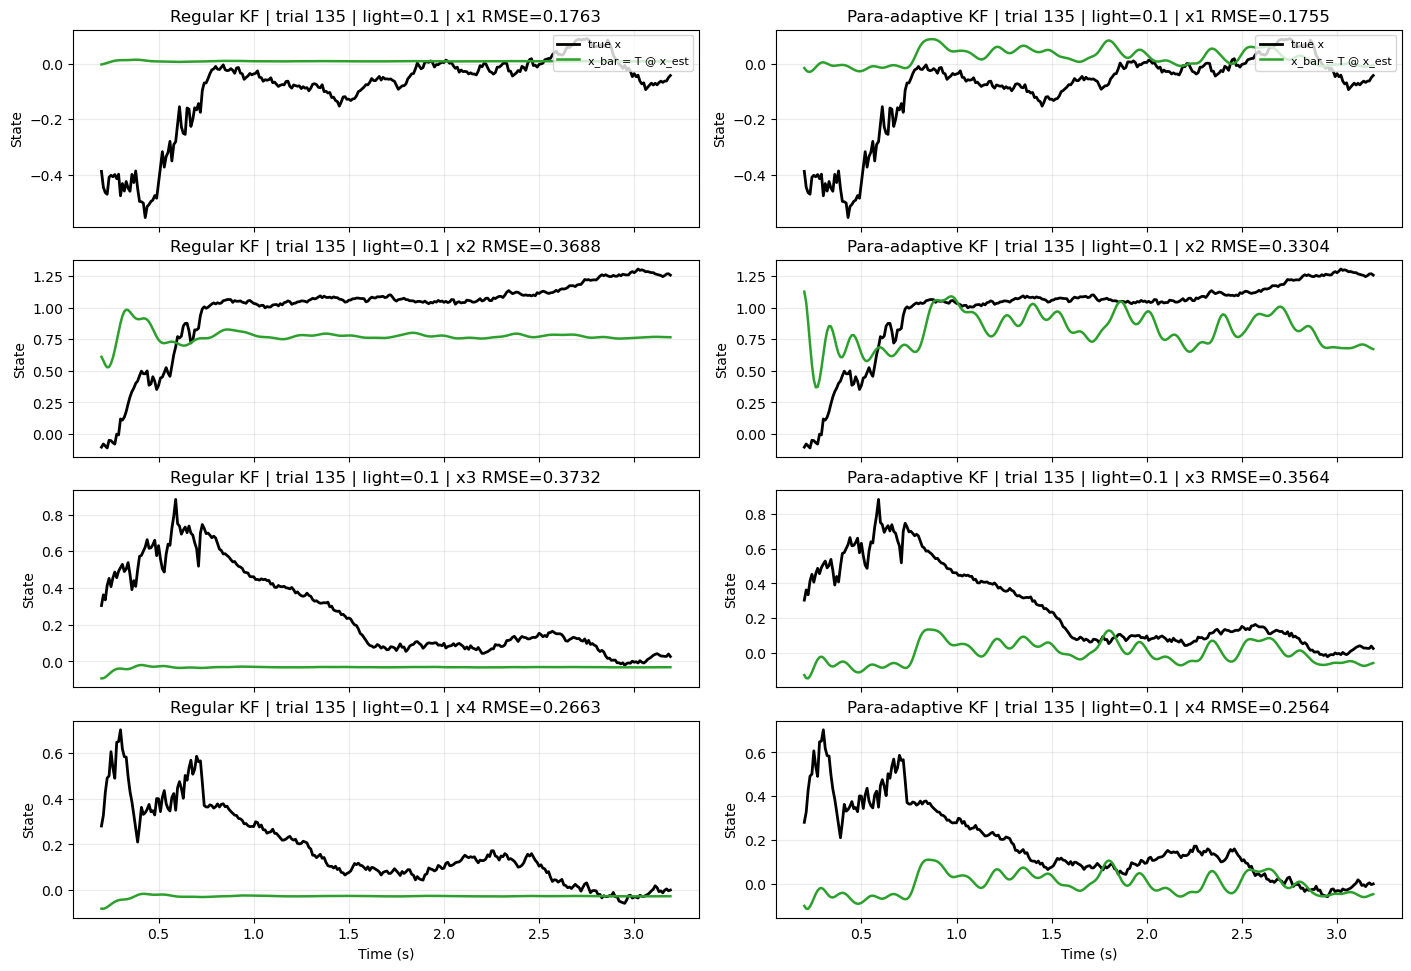

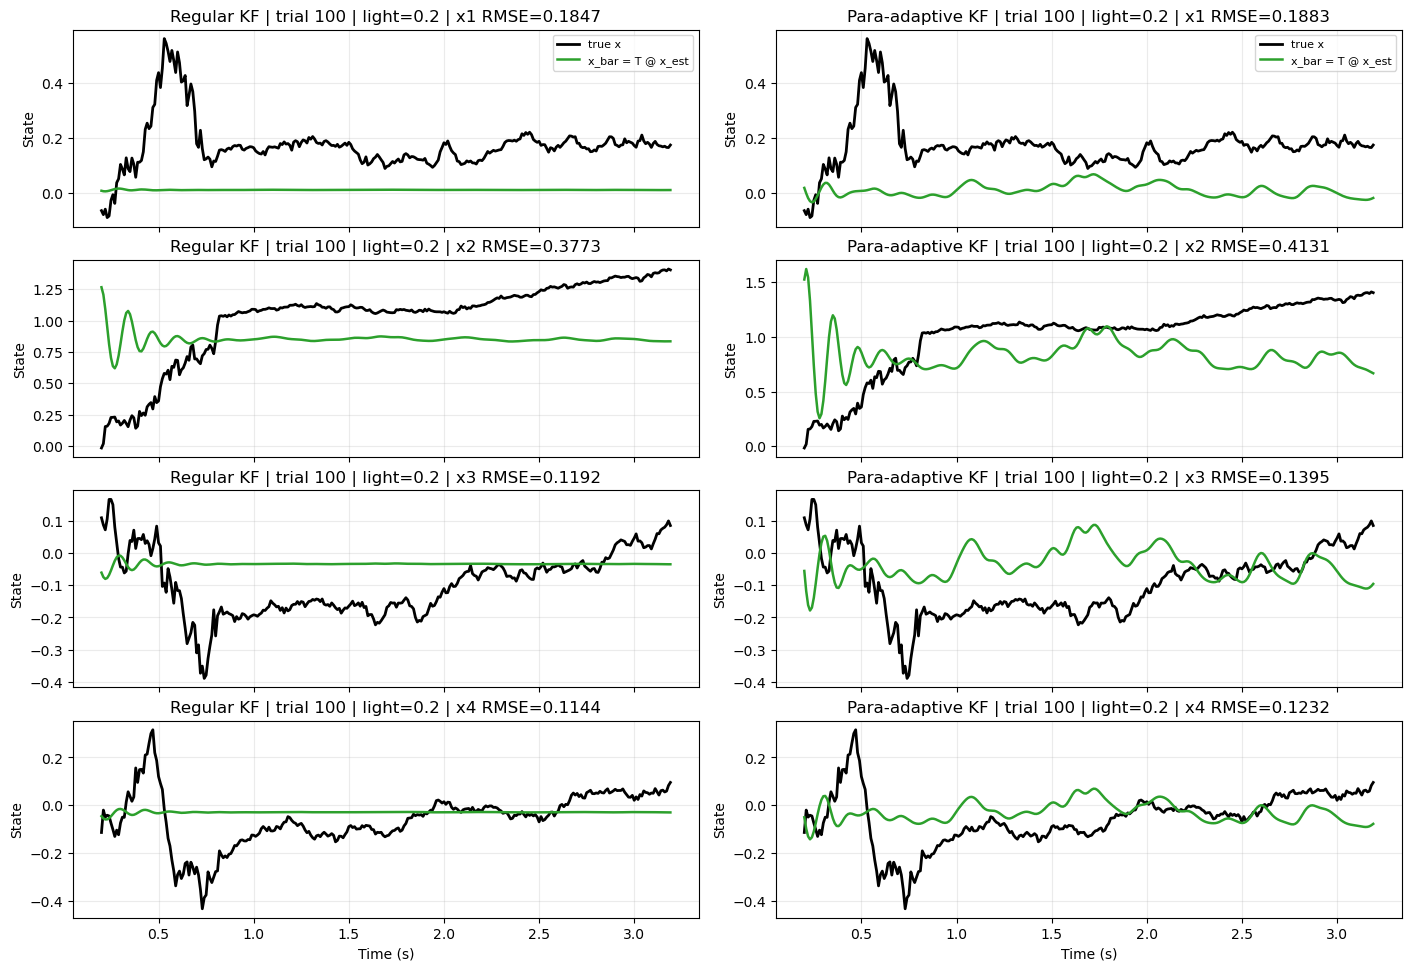

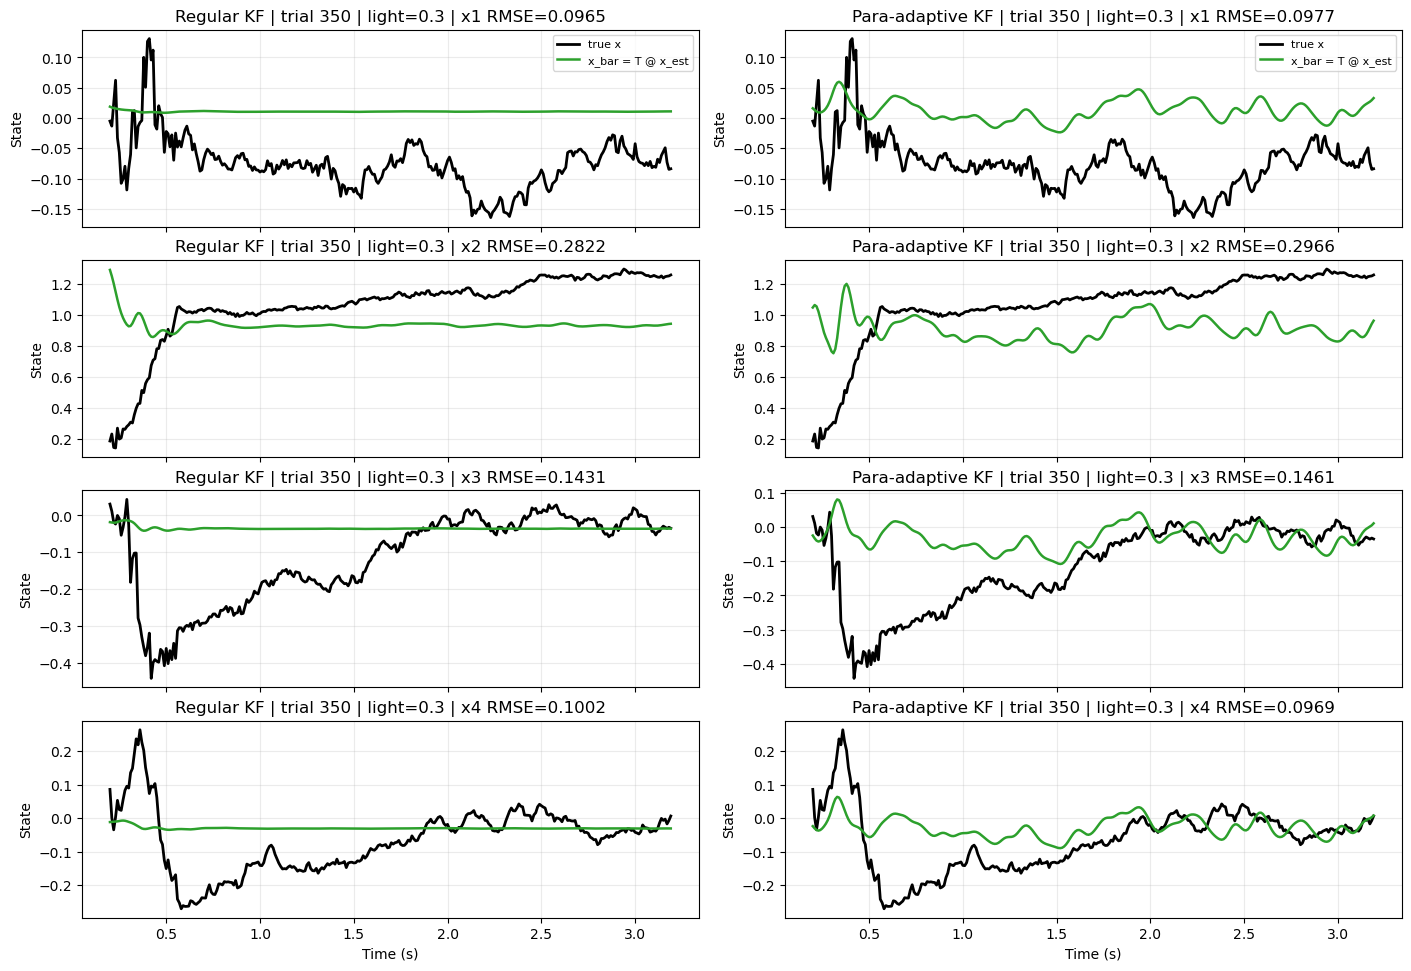

In [86]:
# Plot selected held-out example trials with only true x and transformed x_bar.
# Each subplot title reports RMSE(true x, x_bar) for that trial and x dimension.
if "kf_transform" not in globals() or "para_transform" not in globals():
    raise RuntimeError("Run the T-transform cell above first so kf_transform and para_transform exist.")

transform_results = [kf_transform, para_transform]

if "example_trials_df" not in globals() or example_trials_df.empty:
    example_trials_df = select_example_test_trials_by_light(kf_transform, TRANSFORM_EXAMPLE_LIGHT_INTENSITIES)


def plot_example_trial_transformed_only(example_trial, transform_results):
    x_dim_count = transform_results[0]["arrays"]["x_true"].shape[1]
    fig, axes = plt.subplots(x_dim_count, len(transform_results), figsize=(14, 2.4 * x_dim_count), sharex=True, constrained_layout=True)
    if x_dim_count == 1:
        axes = np.asarray([axes])
    axes = np.atleast_2d(axes)

    for col_idx, result in enumerate(transform_results):
        arrays = result["arrays"]
        trial_mask = arrays["trial_index"] == int(example_trial)
        trial_light = float(arrays["light_intensity"][trial_mask][0])

        for dim_idx in range(x_dim_count):
            x_true_trial = arrays["x_true"][trial_mask, dim_idx]
            x_bar_trial = result["x_bar"][trial_mask, dim_idx]
            trial_dim_rmse = compute_rmse(x_true_trial, x_bar_trial)

            ax = axes[dim_idx, col_idx]
            ax.plot(arrays["time_s"][trial_mask], x_true_trial, color="black", linewidth=2.0, label="true x")
            ax.plot(arrays["time_s"][trial_mask], x_bar_trial, color="tab:green", linewidth=1.8, label="x_bar = T @ x_est")
            ax.set_title(
                f"{result['label']} | trial {int(example_trial)} | light={trial_light:g} | "
                f"x{dim_idx + 1} RMSE={trial_dim_rmse:.4f}"
            )
            ax.set_ylabel("State")
            ax.grid(True, alpha=0.25)
            if dim_idx == 0:
                ax.legend(loc="upper right", fontsize=8)

    for ax in axes[-1, :]:
        ax.set_xlabel("Time (s)")

    return fig


print("Example trials plotted without raw estimated x:")
display(example_trials_df[["trial_index", "light_intensity", "true_x_abs_max", "true_x_std"]])

for example_trial in example_trials_df["trial_index"].astype(int):
    fig = plot_example_trial_transformed_only(example_trial, transform_results)
    plt.show()
